# Ranking graczy NBA Playoffs 2023/24
## Metody Analizy Danych - Projekt 1a

**Autorzy:**
- Filip Michalak (s227830)
- Jakub Michalski (s230987)
- Marek Najmóła (s227946)

**Data:** 14.04.2026


## Streszczenie

Celem niniejszej pracy jest porządkowanie (ranking) graczy NBA Playoffs sezonu 2023/24
przy użyciu trzech metod wielokryterialnej analizy decyzyjnej: SAW (*Simple Additive Weighting*),
TOPSIS (*Technique for Order of Preference by Similarity to Ideal Solution*) oraz metody
syntetycznego miernika rozwoju Hellwiga.
Analizę przeprowadzono na zbiorze 117 graczy (po filtracji: min. 4 mecze, min. 15 minut/mecz),
opisanych 8 zmiennymi diagnostycznymi (6 stymulant i 2 destymulanty).
Wyniki wskazują na wysoką zgodność rankingów SAW i TOPSIS (ρ Spearmana = 0,987),
przy umiarkowanej korelacji obu metod z rankingiem Hellwiga (ρ = 0,84-0,88).
Różnice wynikają z zastosowania wag eksperckich w SAW/TOPSIS vs. równoważenia zmiennych w Hellwigu.
Najlepszymi graczami wg średniej rangi okazali się Nikola Jokić, LeBron James i Shai Gilgeous-Alexander.

**Słowa kluczowe:** ranking wielokryterialny, SAW, TOPSIS, metoda Hellwiga, NBA Playoffs, analiza danych


## 1. Wprowadzenie

Współczesny sport profesjonalny generuje ogromne ilości danych statystycznych.
W koszykówce NBA każdy mecz dostarcza dziesiątki wskaźników opisujących skuteczność
poszczególnych graczy - od punktów i zbiórek, po zaawansowane miary efektywności rzutowej.

Faza play-off NBA stanowi szczególnie interesujący obiekt analizy, ponieważ
gra staje się wolniejsza, bardziej taktyczna, a stawka poszczególnych meczów
jest znacznie wyższa niż w sezonie regularnym. Każdy punkt, zbiórka czy asysta
ma większą wagę, a gracze o najwyższych umiejętnościach mają szansę wyróżnić się
na tle rywali.

**Cel pracy:** Sporządzenie rankingu graczy NBA Playoffs 2023/24 z wykorzystaniem
trzech metod porządkowania obiektów wielokryterialnych oraz porównanie uzyskanych
wyników.

**Metody:**
1. **SAW** (Simple Additive Weighting) z normalizacją min-max
2. **TOPSIS** (Technique for Order of Preference by Similarity to Ideal Solution) z normalizacją wektorową
3. **Metoda Hellwiga** ze standaryzacją z-score

Praca jest zrealizowana w ramach projektu z przedmiotu *Metody Analizy Danych* (wariant 1a - porządkowanie obiektów).


## 2. Przegląd literatury

Wielokryterialna analiza decyzyjna (*Multi-Criteria Decision Analysis*, MCDA) jest szeroko
stosowana w porządkowaniu obiektów opisanych wieloma zmiennymi. Trzy metody wybrane
w niniejszej pracy należą do najczęściej cytowanych podejść w literaturze.

**Metoda SAW** (*Simple Additive Weighting*) jest najprostszą techniką MCDA.
Polega na normalizacji wartości kryterialnych i obliczeniu sumy ważonej.
Jest powszechnie stosowana ze względu na intuicyjność i łatwość interpretacji.

**Metoda TOPSIS** została zaproponowana przez Hwanga i Yoona. Opiera się
na wyznaczeniu odległości każdego obiektu od rozwiązania idealnego (najlepszego)
i anty-idealnego (najgorszego). Obiekt o największym stosunku odległości od anty-ideału
do sumy odległości od obu rozwiązań referencyjnych zajmuje najwyższą pozycję.
Metoda ta uwzględnia jednocześnie bliskość do ideału i oddalenie od anty-ideału,
co stanowi jej przewagę nad prostszymi podejściami.

**Metoda Hellwiga** jest polskim wkładem w taksonomię
numeryczną, zaproponowanym przez Zdzisława Hellwiga. Metoda polega na
standaryzacji zmiennych, wyznaczeniu wzorca rozwoju oraz obliczeniu odległości
euklidesowych obiektów od tego wzorca. Syntetyczny miernik przyjmuje wartości
bliskie 1 dla obiektów najbliższych wzorcowi.

W kontekście sportu metody MCDA były stosowane m.in. do rankingowania drużyn
piłkarskich oraz oceny efektywności zawodników NBA.


## 3. Opis zmiennych

### 3.1. Wybrane zmienne diagnostyczne (8)

Wybrano 8 zmiennych opisujących kluczowe aspekty gry koszykarza
- ofensywne (punkty, asysty, efektywność rzutowa), defensywne (zbiórki, przechwyty, bloki)
oraz negatywne (straty, faule):

| Nr | Zmienna | Opis | Charakter | Waga |
|----|---------|------|-----------|------|
| 1 | **PTS** | Punkty na mecz | Stymulanta | 0,25 |
| 2 | **TRB** | Zbiórki na mecz | Stymulanta | 0,15 |
| 3 | **AST** | Asysty na mecz | Stymulanta | 0,18 |
| 4 | **STL** | Przechwyty na mecz | Stymulanta | 0,10 |
| 5 | **BLK** | Bloki na mecz | Stymulanta | 0,08 |
| 6 | **eFG%** | Efektywna skuteczność rzutowa | Stymulanta | 0,14 |
| 7 | **TOV** | Straty na mecz | Destymulanta | 0,05 |
| 8 | **PF** | Faule osobiste na mecz | Destymulanta | 0,05 |

**Suma wag = 1,00**

### 3.2. Uzasadnienie wag eksperckich

- **PTS (0,25)** - Punkty są najważniejszym wyznacznikiem skuteczności ofensywnej w play-offach, gdzie każdy kosz ma dużą wagę.
- **AST (0,18)** - Asysty mierzą zdolność kreowania gry; kluczowe dla rozgrywających i liderów drużyn.
- **TRB (0,15)** - Zbiórki dają drugie szanse ataku (ofensywne) i kończą ataki rywala (defensywne).
- **eFG% (0,14)** - Efektywność rzutowa uwzględniająca wartość rzutów za 3 pkt; syntetyczna miara precyzji.
- **STL (0,10)** - Przechwyty generują szybkie ataki i odzwierciedlają aktywność defensywną.
- **BLK (0,08)** - Bloki chronią obręcz; ważne, ale rzadsze niż przechwyty.
- **TOV (0,05)** - Straty są kosztowne, ale nawet najlepsi gracze mają podwyższone TOV z uwagi na dużą rolę w ataku.
- **PF (0,05)** - Faule obniżają wartość gracza (ryzyko wykluczenia), ale są częściowo efektem agresywnej gry obronnej.

### 3.3. Usunięte zmienne (z uzasadnieniem)

- **3P%, FT%** - Procenty z zerową liczbą prób (0/0) dają 0%, co nie oznacza niskiej umiejętności, a jedynie brak prób. Np. Rudy Gobert ma 3P% = 0 (0 z 0 prób za 3 pkt), a Dereck Lively II ma 3P% = 1.0 (1/1). **eFG%** jest lepszą syntetyczną miarą skuteczności rzutowej.
- **MP (minuty na mecz)** - Dane są już średnimi per-game, więc czas gry jest pośrednio wbudowany w wartości bezwzględne (PTS, TRB, AST, ...). Włączenie MP powodowałoby podwójne liczenie i silną korelację z PTS (r > 0,8).


## 4. Wstępna analiza danych

### 4.1. Wczytanie i przygotowanie danych


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats
from pathlib import Path

# Konfiguracja wykresow
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
sns.set_style("whitegrid")

PLOTS_DIR = Path("output/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Konfiguracja zmiennych i wag ---
STIMULANTS = ["PTS", "TRB", "AST", "STL", "BLK", "eFG%"]
DESTIMULANTS = ["TOV", "PF"]
ALL_VARIABLES = STIMULANTS + DESTIMULANTS

WEIGHTS = {
    "PTS": 0.25, "AST": 0.18, "TRB": 0.15, "eFG%": 0.14,
    "STL": 0.10, "BLK": 0.08, "TOV": 0.05, "PF": 0.05,
}

print(f"Suma wag: {sum(WEIGHTS.values()):.2f}")
print(f"Stymulanty ({len(STIMULANTS)}): {STIMULANTS}")
print(f"Destymulanty ({len(DESTIMULANTS)}): {DESTIMULANTS}")


Suma wag: 1.00
Stymulanty (6): ['PTS', 'TRB', 'AST', 'STL', 'BLK', 'eFG%']
Destymulanty (2): ['TOV', 'PF']


In [19]:
# --- Funkcja do renderowania tabeli ---
def render_table(df, title="", filename=None, col_widths=None, highlight_col=None,
                 fontsize=9, header_color="#4C72B0", row_colors=("#f7f7f7", "#ffffff"),
                 title_fontsize=13, figscale=1.0):
    nrows, ncols = df.shape
    fig_width = max(ncols * 1.4 * figscale, 8)
    row_h = 0.35
    fig_height = (nrows + 1) * row_h * figscale + (0.8 if title else 0.3)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    tbl = ax.table(cellText=df.values, colLabels=df.columns,
                   cellLoc="center", loc="upper center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1.0, 1.6)

    for j in range(ncols):
        cell = tbl[0, j]
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold", fontsize=fontsize)
        cell.set_edgecolor("white")

    for i in range(1, nrows + 1):
        bg = row_colors[0] if i % 2 == 1 else row_colors[1]
        for j in range(ncols):
            cell = tbl[i, j]
            cell.set_facecolor(bg)
            cell.set_edgecolor("#dddddd")
            if highlight_col is not None and j == highlight_col:
                cell.set_text_props(fontweight="bold")

    if col_widths:
        for j, w in enumerate(col_widths):
            for i in range(nrows + 1):
                tbl[i, j].set_width(w)
    else:
        tbl.auto_set_column_width(list(range(ncols)))

    if title:
        ax.set_title(title, fontsize=title_fontsize, fontweight="bold",
                     pad=12, loc="center")

    fig.tight_layout()

    if filename:
        fig.savefig(PLOTS_DIR / f"{filename}.png", dpi=150, bbox_inches="tight",
                    facecolor="white", edgecolor="none")

    plt.show()


In [20]:
# Wczytanie danych
df_raw = pd.read_csv("Playoffs.csv", sep=";")

if "Rk" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Rk"])

# Konwersja kolumn numerycznych
numeric_cols = [c for c in df_raw.columns if c not in ("Player", "Pos", "Tm")]
for col in numeric_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

print(f"Surowy zbior danych: {len(df_raw)} graczy, {len(df_raw.columns)} kolumn")
print(f"\nPrzykladowe dane (5 pierwszych graczy):")
df_raw[["Player", "Pos", "Tm", "G", "MP"] + ALL_VARIABLES].head()


Surowy zbior danych: 214 graczy, 29 kolumn

Przykladowe dane (5 pierwszych graczy):


,Player,Pos,Tm,G,MP,PTS,TRB,AST,STL,BLK,eFG%,TOV,PF
0,Precious Achiuwa,PF,NYK,9,20.4,5.2,4.2,0.6,0.4,1.3,0.488,0.4,2.2
1,Bam Adebayo,C,MIA,5,38.4,22.6,9.4,3.8,0.4,0.0,0.505,1.6,3.0
2,Nickeil Alexander-Walker,SG,MIN,16,23.6,7.3,1.8,2.3,0.6,0.4,0.473,0.9,1.5
3,Grayson Allen,SG,PHO,2,21.5,3.5,4.0,1.0,0.5,0.0,0.300,1.5,2.0
4,Jarrett Allen,C,CLE,4,31.8,17.0,13.8,1.3,1.3,1.0,0.676,1.3,2.0


In [21]:
# Filtracja: minimum 4 mecze i 15 minut na mecz
MIN_GAMES = 4
MIN_MP = 15.0

n_before = len(df_raw)
df = df_raw[(df_raw["G"] >= MIN_GAMES) & (df_raw["MP"] >= MIN_MP)].copy()
df = df.reset_index(drop=True)

print(f"Przed filtracja: {n_before} graczy")
print(f"Po filtracji (G >= {MIN_GAMES}, MP >= {MIN_MP}): {len(df)} graczy")
print(f"\nRozklad pozycji:")
print(df["Pos"].value_counts().sort_index().to_string())


Przed filtracja: 214 graczy
Po filtracji (G >= 4, MP >= 15.0): 117 graczy

Rozklad pozycji:
Pos
C     22
PF    24
PG    24
SF    22
SG    25


### 4.2. Braki danych

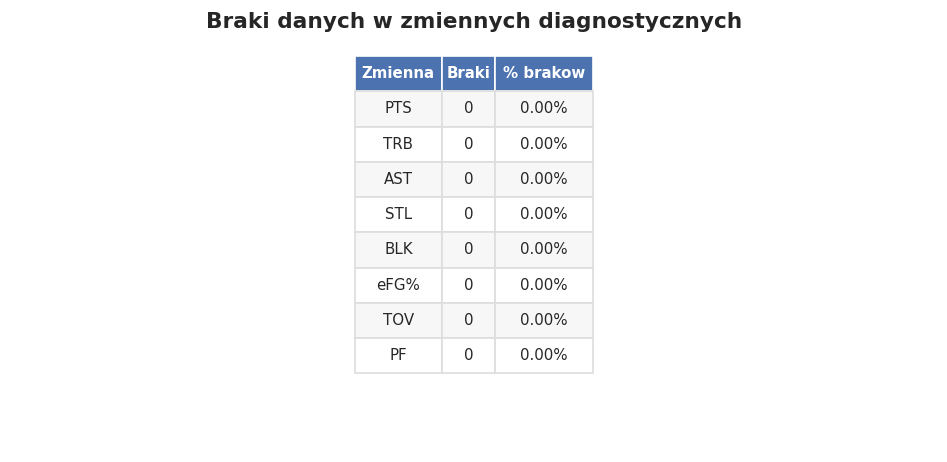

=> Brak brakow danych w wybranych zmiennych. Imputacja nie jest wymagana.


In [22]:
# Sprawdzenie brakow danych w zmiennych diagnostycznych
missing_info = []
for var in ALL_VARIABLES:
    n_miss = df[var].isna().sum()
    missing_info.append({
        "Zmienna": var,
        "Braki": n_miss,
        "% brakow": f"{100 * n_miss / len(df):.2f}%"
    })

missing_df = pd.DataFrame(missing_info)
render_table(missing_df, title="Braki danych w zmiennych diagnostycznych",
             filename="tab_missing_data")

if missing_df["Braki"].sum() == 0:
    print("=> Brak brakow danych w wybranych zmiennych. Imputacja nie jest wymagana.")
else:
    print("=> Braki danych uzupelniono mediana.")
    for var in ALL_VARIABLES:
        if df[var].isna().any():
            df[var] = df[var].fillna(df[var].median())


### 4.3. Statystyki opisowe

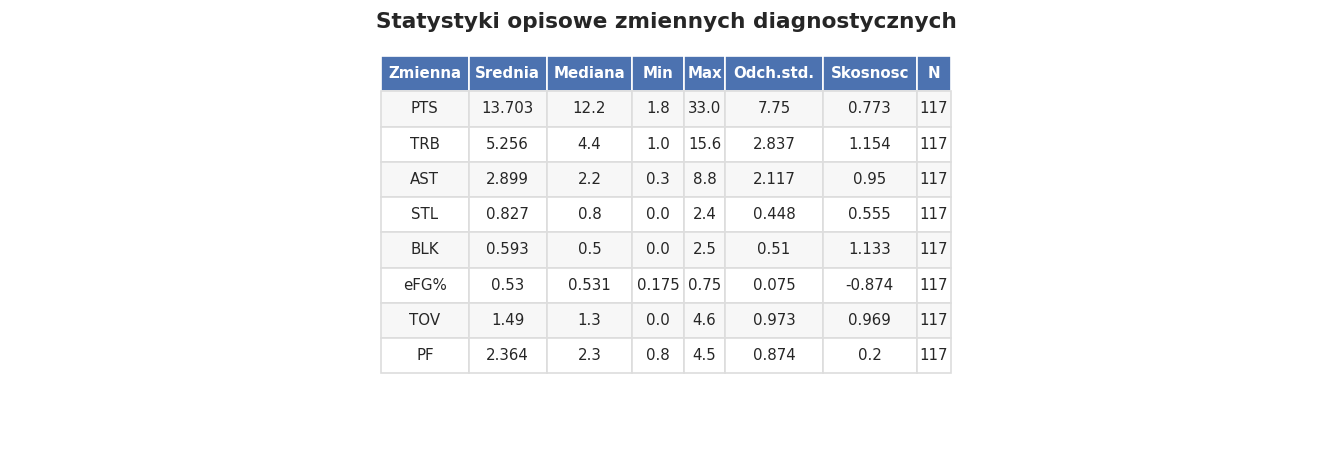

In [23]:
records = []
for var in ALL_VARIABLES:
    vals = df[var].dropna()
    records.append({
        "Zmienna": var,
        "Srednia": round(vals.mean(), 3),
        "Mediana": round(vals.median(), 3),
        "Min": round(vals.min(), 3),
        "Max": round(vals.max(), 3),
        "Odch.std.": round(vals.std(ddof=1), 3),
        "Skosnosc": round(sp_stats.skew(vals, bias=False), 3),
        "N": len(vals),
    })

stats_df = pd.DataFrame(records)
render_table(stats_df, title="Statystyki opisowe zmiennych diagnostycznych",
             filename="tab_descriptive_stats")


**Komentarz do statystyk opisowych:**

- **PTS** (punkty): Średnia 13,7 pkt/mecz, mediana 12,2 - rozkład prawoskośny (skośność 0,77), co oznacza grupę elitarnych zawodników z wyraźnie wyższymi wynikami.
- **TRB** (zbiórki): Średnia 5,3, mediana 4,4 - silna prawoskośność (1,15), dominacja środkowych i silnych skrzydłowych.
- **AST** (asysty): Średnia 2,9, mediana 2,2 - rozkład prawoskośny (0,95); rozgrywający mają znacznie więcej asyst.
- **eFG%**: Średnia 0,530, niska zmienność (std = 0,075), lekko lewoskośny (-0,87) - kilku graczy z wyjątkowo niską skutecznością.
- **TOV** (straty): Średnia 1,49, mediana 1,3 - prawoskośny; najlepsi gracze tracą piłkę częściej (większa odpowiedzialność).
- **PF** (faule): Średnia 2,36, mała skośność (0,20) - najbardziej symetryczny rozkład ze wszystkich zmiennych.


### 4.4. Wykresy pudełkowe (boxploty)

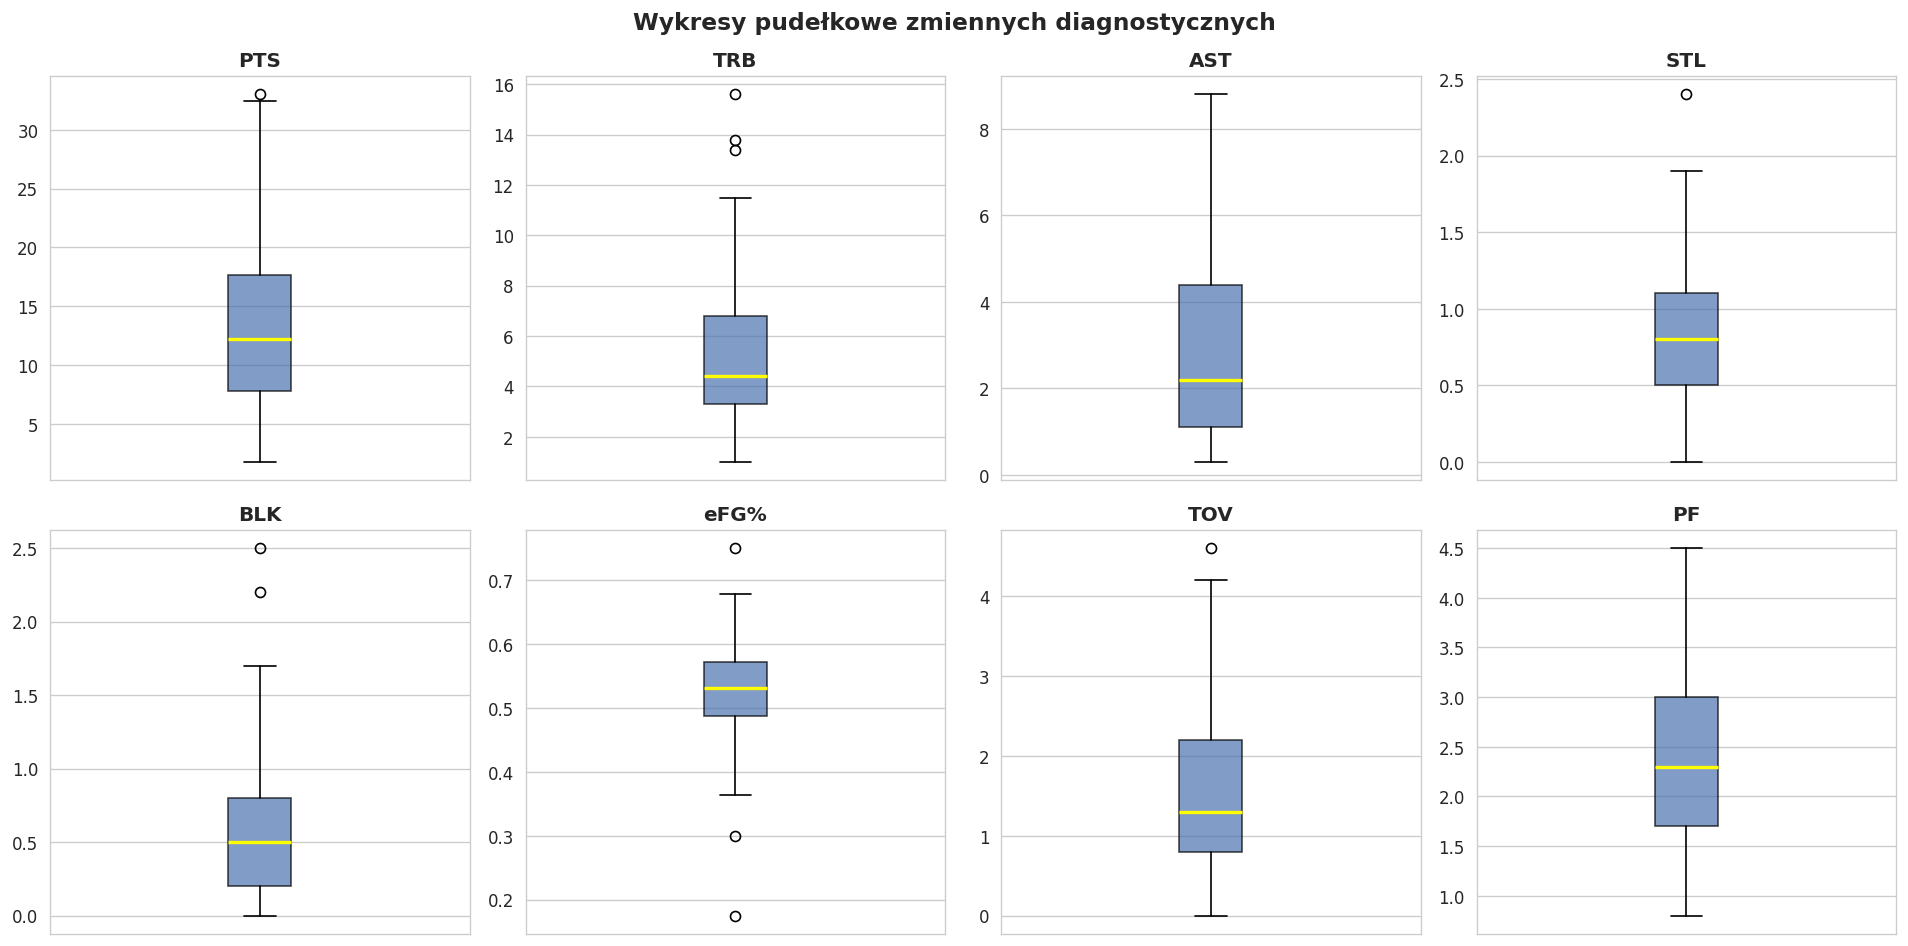

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(ALL_VARIABLES):
    ax = axes[i]
    vals = df[var].dropna()
    bp = ax.boxplot(vals, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#4C72B0", alpha=0.7),
                    medianprops=dict(color="yellow", linewidth=2))
    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_xticks([])

fig.suptitle("Wykresy pudełkowe zmiennych diagnostycznych", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


### 4.5. Histogramy

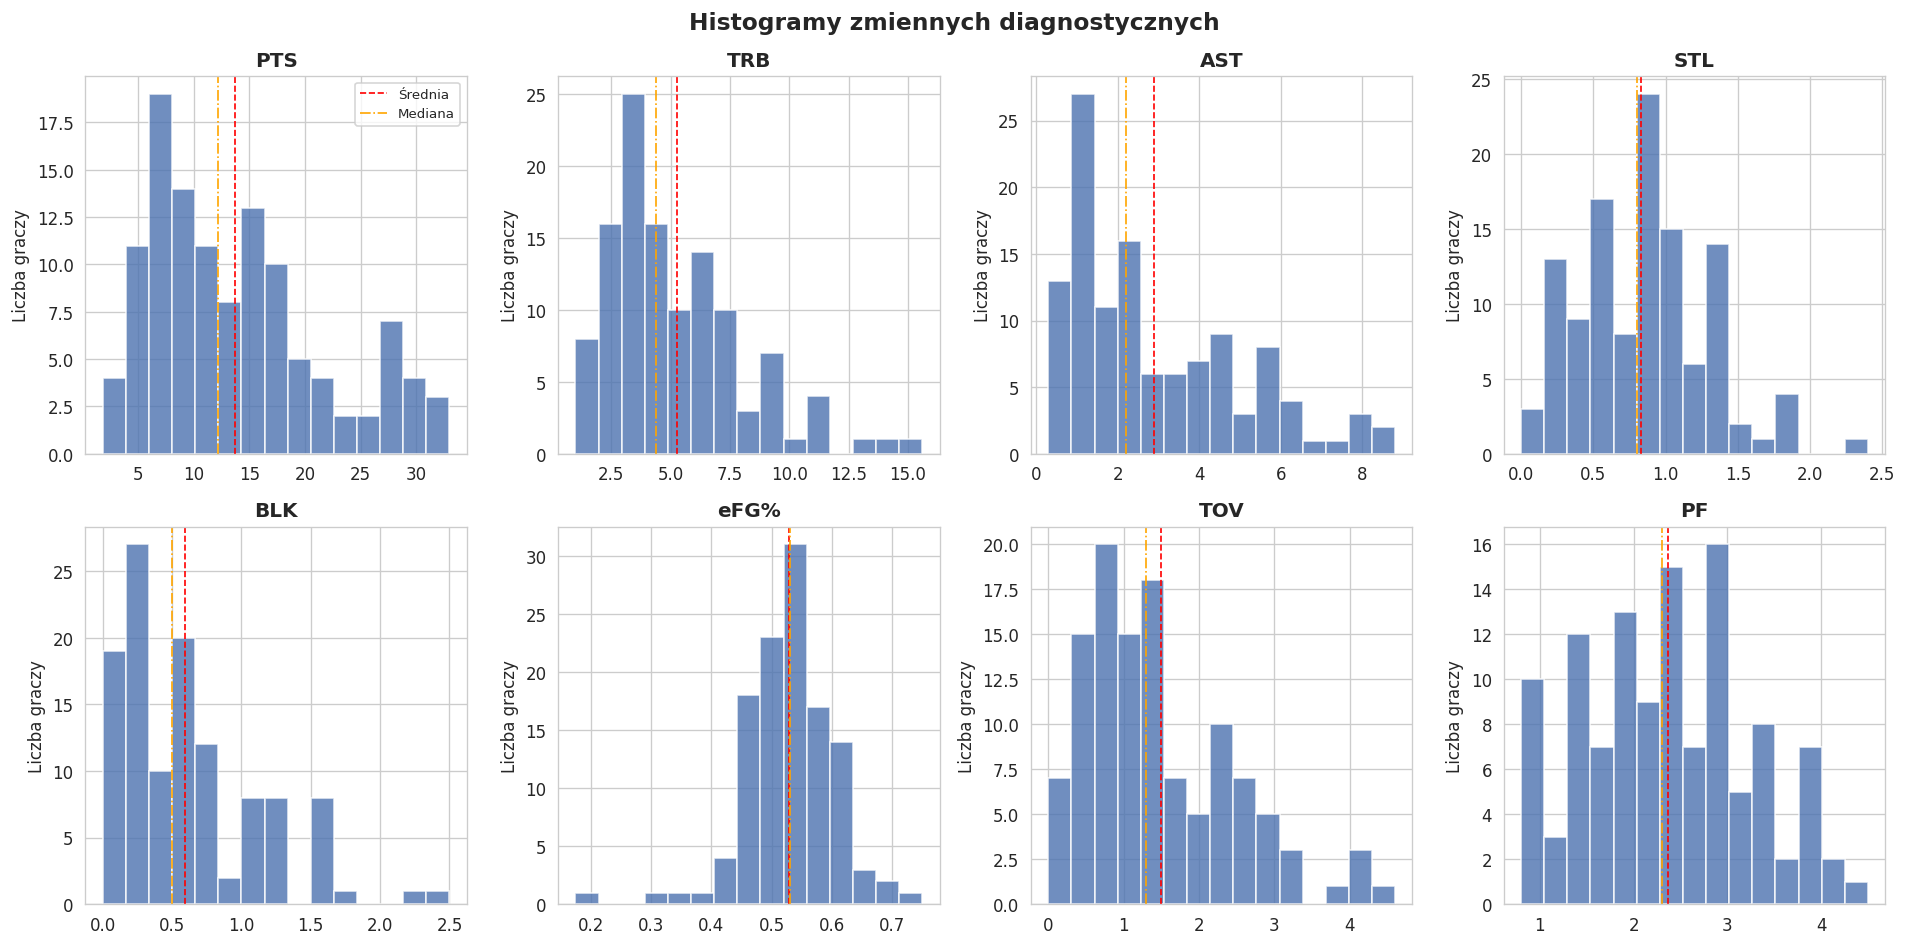

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(ALL_VARIABLES):
    ax = axes[i]
    vals = df[var].dropna()
    ax.hist(vals, bins=15, color="#4C72B0", alpha=0.8, edgecolor="white")
    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_ylabel("Liczba graczy")
    ax.axvline(vals.mean(), color="red", linestyle="--", linewidth=1, label="Średnia")
    ax.axvline(vals.median(), color="orange", linestyle="-.", linewidth=1, label="Mediana")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Histogramy zmiennych diagnostycznych", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


### 4.6. Obserwacje odstające (metoda IQR)

Wykryto 11 obserwacji odstajacych:


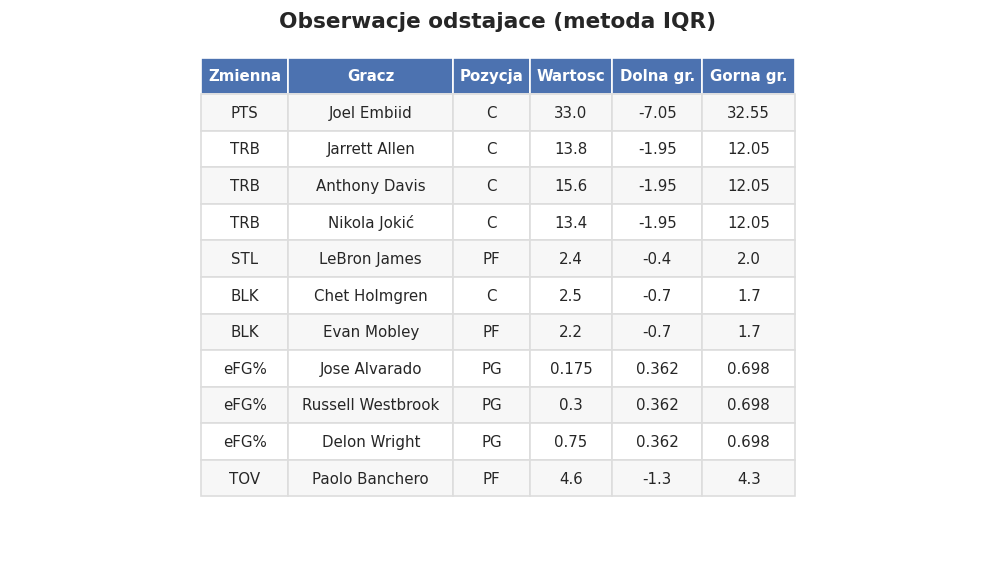

In [26]:
outlier_records = []
for var in ALL_VARIABLES:
    vals = df[var].dropna()
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[var] < lower) | (df[var] > upper)
    outliers = df.loc[mask, ["Player", "Pos", var]]
    for _, row in outliers.iterrows():
        outlier_records.append({
            "Zmienna": var,
            "Gracz": row["Player"],
            "Pozycja": row["Pos"],
            "Wartosc": row[var],
            "Dolna gr.": round(lower, 3),
            "Gorna gr.": round(upper, 3),
        })

outliers_df = pd.DataFrame(outlier_records)
print(f"Wykryto {len(outliers_df)} obserwacji odstajacych:")
render_table(outliers_df, title="Obserwacje odstajace (metoda IQR)",
             filename="tab_outliers")


**Decyzja:** Obserwacje odstające **nie są usuwane**.

**Uzasadnienie:** W kontekście sportu wartości skrajne reprezentują elitarnych graczy
(np. Joel Embiid - 33 pkt/mecz, Anthony Davis - 15,6 zbiórek/mecz). Ich usunięcie
zniekształciłoby ranking, gdyż właśnie ci gracze powinni zajmować czołowe pozycje.
Metody rankingowe (SAW, TOPSIS, Hellwig) są odporne na obserwacje odstające dzięki
mechanizmom normalizacji.


### 4.7. Macierz korelacji

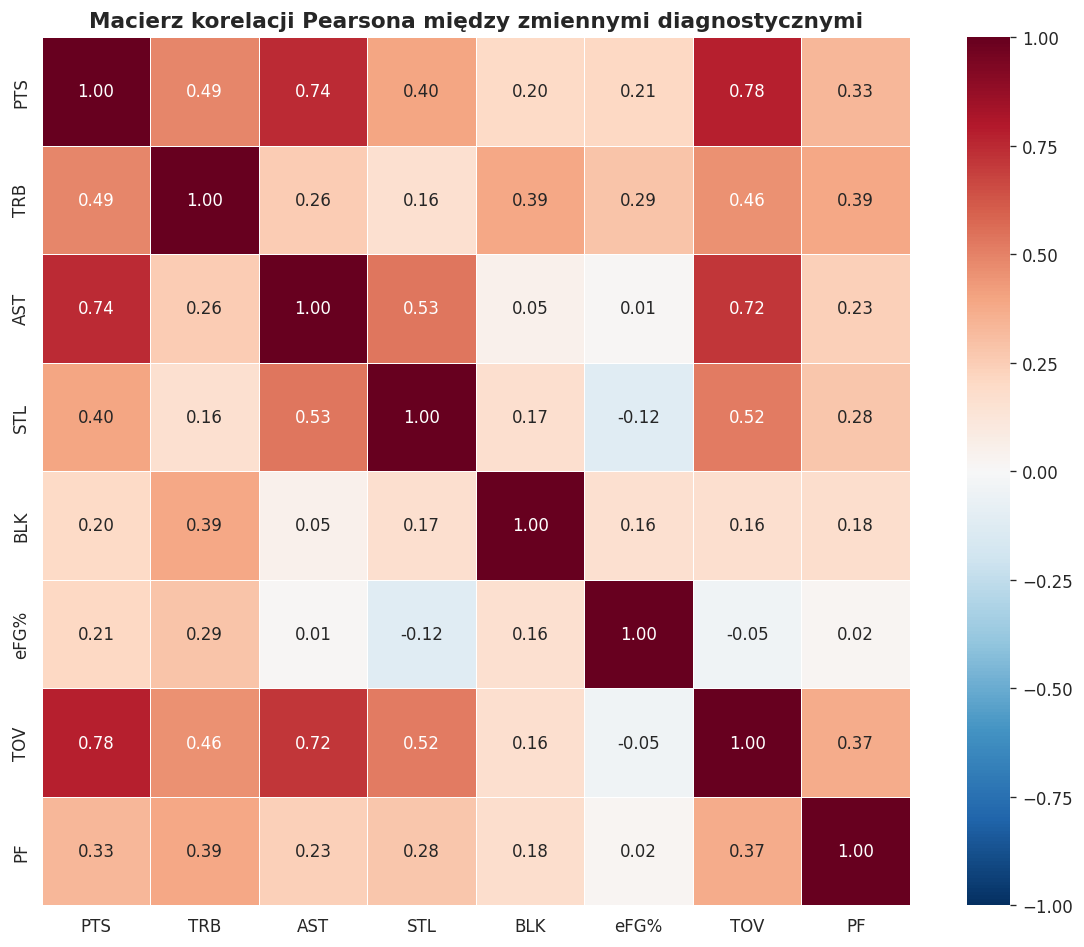


Najsilniejsze korelacje (|r| > 0.5):
  PTS <=> AST: r = 0.744
  PTS <=> TOV: r = 0.781
  AST <=> STL: r = 0.532
  AST <=> TOV: r = 0.719
  STL <=> TOV: r = 0.521


In [27]:
corr = df[ALL_VARIABLES].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr, dtype=bool)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=ALL_VARIABLES, yticklabels=ALL_VARIABLES,
            vmin=-1, vmax=1)
ax.set_title("Macierz korelacji Pearsona między zmiennymi diagnostycznymi",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("\nNajsilniejsze korelacje (|r| > 0.5):")
for i in range(len(ALL_VARIABLES)):
    for j in range(i+1, len(ALL_VARIABLES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {ALL_VARIABLES[i]} <=> {ALL_VARIABLES[j]}: r = {r:.3f}")


**Komentarz do korelacji:**

- **PTS <=> TOV (r ~ 0,78):** Gracze z dużą liczbą punktów częściej tracą piłkę - jest to oczekiwane, ponieważ liderzy ofensywni mają piłkę w rękach znacznie częściej.
- **PTS <=> AST (r ~ 0,74):** Najlepsi strzelcy jednocześnie kreują grę dla kolegów.
- **PTS <=> TRB (r ~ 0,50):** Gracze dominujący na tablicach często też zdobywają dużo punktów (typowe dla centrów i power forwardów).
- **AST <=> TOV (r ~ 0,62):** Rozgrywający, którzy dużo asystują, również częściej tracą piłkę.

**Ważne:** Korelacje te są oczekiwane w koszykówce i **nie dyskwalifikują zmiennych** w metodach rankingowych.
W odróżnieniu od regresji, w SAW, TOPSIS i Hellwigu współliniowość nie powoduje niestabilności wyników,
ponieważ każda zmienna mierzy inny aspekt gry (ofensywa, obrona, kreacja, efektywność).


## 5. Metody rankingowe

### 5.1. SAW - Simple Additive Weighting

Metoda SAW polega na normalizacji wartości zmiennych
do przedziału $[0, 1]$ metodą min-max, a następnie obliczeniu ważonej sumy znormalizowanych wartości.

**Normalizacja min-max:**

Dla stymulanty:
$$r_{ij} = \frac{x_{ij} - x_{j}^{\min}}{x_{j}^{\max} - x_{j}^{\min}}$$

Dla destymulanty:
$$r_{ij} = \frac{x_{j}^{\max} - x_{ij}}{x_{j}^{\max} - x_{j}^{\min}}$$

**Wskaźnik syntetyczny:**
$$S_i = \sum_{j=1}^{m} w_j \cdot r_{ij}$$

gdzie $w_j$ - waga $j$-tej zmiennej, $\sum w_j = 1$.


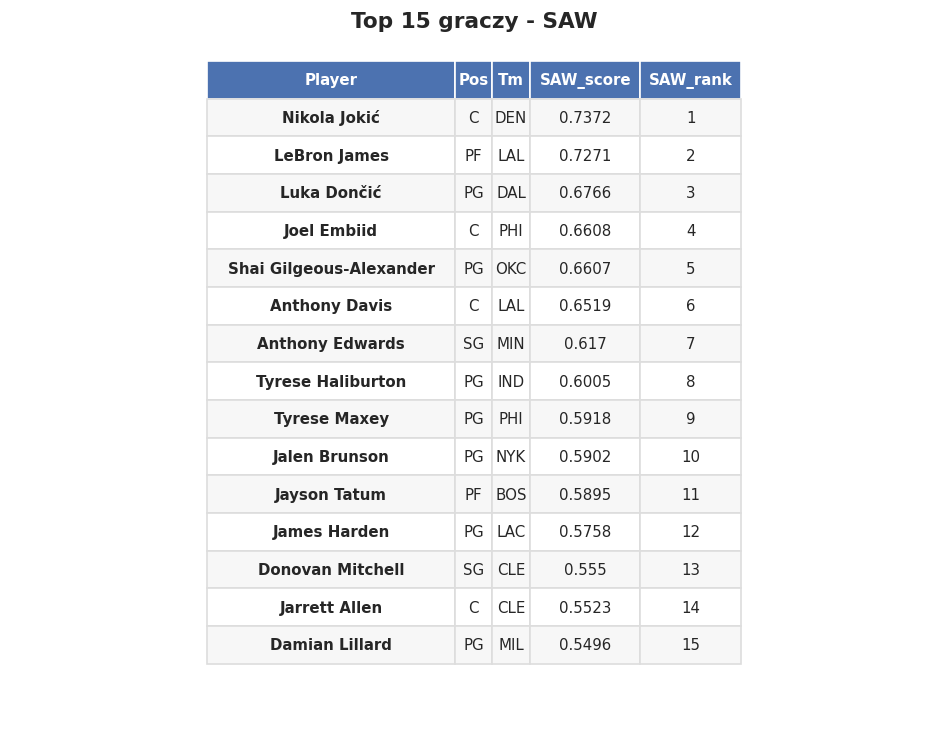

In [28]:
def ranking_saw(df, stimulants, destimulants, weights):
    result = df[["Player", "Pos", "Tm"]].copy()
    all_vars = stimulants + destimulants

    for var in all_vars:
        vals = df[var].values.astype(float)
        v_min, v_max = vals.min(), vals.max()
        denom = v_max - v_min
        if denom == 0:
            result[f"{var}_norm"] = 0.0
        elif var in stimulants:
            result[f"{var}_norm"] = (vals - v_min) / denom
        else:
            result[f"{var}_norm"] = (v_max - vals) / denom

    score = np.zeros(len(result))
    for var in all_vars:
        w = weights.get(var, 0.0)
        score += w * result[f"{var}_norm"].values
    result["SAW_score"] = score
    result["SAW_rank"] = result["SAW_score"].rank(ascending=False, method="min").astype(int)
    result = result.sort_values("SAW_rank").reset_index(drop=True)

    norm_cols = [c for c in result.columns if c.endswith("_norm")]
    result = result.drop(columns=norm_cols)
    return result

saw_df = ranking_saw(df, STIMULANTS, DESTIMULANTS, WEIGHTS)
top15_saw = saw_df[["Player", "Pos", "Tm", "SAW_score", "SAW_rank"]].head(15).copy()
top15_saw["SAW_score"] = top15_saw["SAW_score"].round(4)
render_table(top15_saw, title="Top 15 graczy - SAW", filename="tab_top15_saw",
             highlight_col=0)


### 5.2. TOPSIS - Technique for Order of Preference by Similarity to Ideal Solution

Metoda TOPSIS opiera się na wyznaczeniu odległości euklidesowej obiektu od rozwiązania
idealnego (najlepszego) i anty-idealnego (najgorszego).

**Krok 1 - Normalizacja wektorowa:**
$$r_{ij} = \frac{x_{ij}}{\sqrt{\sum_{i=1}^{n} x_{ij}^2}}$$

**Krok 2 - Ważona macierz decyzyjna:**
$$v_{ij} = w_j \cdot r_{ij}$$

**Krok 3 - Rozwiązanie idealne $A^+$ i anty-idealne $A^-$:**
$$A^+ = \{v_1^+, v_2^+, \ldots, v_m^+\}, \quad A^- = \{v_1^-, v_2^-, \ldots, v_m^-\}$$
Dla stymulant: $v_j^+ = \max_i v_{ij}$, $v_j^- = \min_i v_{ij}$;
Dla destymulant: $v_j^+ = \min_i v_{ij}$, $v_j^- = \max_i v_{ij}$.

**Krok 4 - Odległości euklidesowe:**
$$d_i^+ = \sqrt{\sum_{j=1}^{m}(v_{ij} - v_j^+)^2}, \quad d_i^- = \sqrt{\sum_{j=1}^{m}(v_{ij} - v_j^-)^2}$$

**Krok 5 - Wskaźnik syntetyczny:**
$$C_i = \frac{d_i^-}{d_i^+ + d_i^-}, \quad C_i \in [0, 1]$$


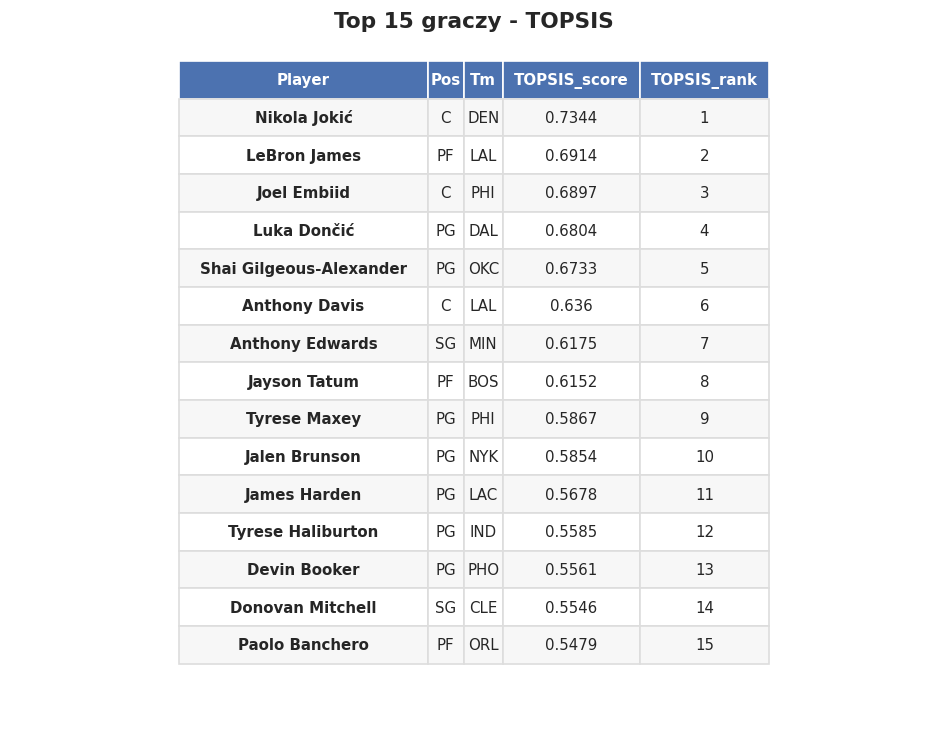

In [29]:
def ranking_topsis(df, stimulants, destimulants, weights):
    result = df[["Player", "Pos", "Tm"]].copy()
    all_vars = stimulants + destimulants
    n = len(df)

    # Normalizacja wektorowa
    norm_matrix = np.zeros((n, len(all_vars)))
    for j, var in enumerate(all_vars):
        vals = df[var].values.astype(float)
        denom = np.sqrt(np.sum(vals ** 2))
        norm_matrix[:, j] = vals / denom if denom != 0 else 0.0

    # Wazona macierz decyzyjna
    w_array = np.array([weights.get(var, 0.0) for var in all_vars])
    weighted = norm_matrix * w_array

    # Rozwiazanie idealne i anty-idealne
    a_plus = np.zeros(len(all_vars))
    a_minus = np.zeros(len(all_vars))
    for j, var in enumerate(all_vars):
        if var in stimulants:
            a_plus[j] = weighted[:, j].max()
            a_minus[j] = weighted[:, j].min()
        else:
            a_plus[j] = weighted[:, j].min()
            a_minus[j] = weighted[:, j].max()

    # Odleglosci euklidesowe
    d_plus = np.sqrt(np.sum((weighted - a_plus) ** 2, axis=1))
    d_minus = np.sqrt(np.sum((weighted - a_minus) ** 2, axis=1))

    denom = d_plus + d_minus
    denom = np.where(denom == 0, 1e-10, denom)
    score = d_minus / denom

    result["TOPSIS_score"] = score
    result["TOPSIS_rank"] = result["TOPSIS_score"].rank(ascending=False, method="min").astype(int)
    result = result.sort_values("TOPSIS_rank").reset_index(drop=True)
    return result

topsis_df = ranking_topsis(df, STIMULANTS, DESTIMULANTS, WEIGHTS)
top15_topsis = topsis_df[["Player", "Pos", "Tm", "TOPSIS_score", "TOPSIS_rank"]].head(15).copy()
top15_topsis["TOPSIS_score"] = top15_topsis["TOPSIS_score"].round(4)
render_table(top15_topsis, title="Top 15 graczy - TOPSIS", filename="tab_top15_topsis",
             highlight_col=0)


### 5.3. Metoda Hellwiga - syntetyczny miernik rozwoju

Metoda Hellwiga nie wykorzystuje wag eksperckich. Zamiast tego standaryzuje
zmienne (z-score) i wyznacza wzorzec rozwoju na podstawie wartości ekstremalnych.

**Krok 1 - Standaryzacja z-score:**
$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

**Krok 2 - Wzorzec rozwoju $z_0$:**
$$z_{0j} = \begin{cases} \max_i z_{ij} & \text{dla stymulant} \\ \min_i z_{ij} & \text{dla destymulant} \end{cases}$$

**Krok 3 - Odległość od wzorca:**
$$d_i = \sqrt{\sum_{j=1}^{m}(z_{ij} - z_{0j})^2}$$

**Krok 4 - Wartość graniczna:**
$$d_0 = \bar{d} + 2 \cdot s_d$$

**Krok 5 - Syntetyczny miernik rozwoju:**
$$S_i = 1 - \frac{d_i}{d_0}, \quad S_i \in (-\infty, 1]$$

Im bliżej 1, tym obiekt jest lepszy (bliższy wzorcowi rozwoju).


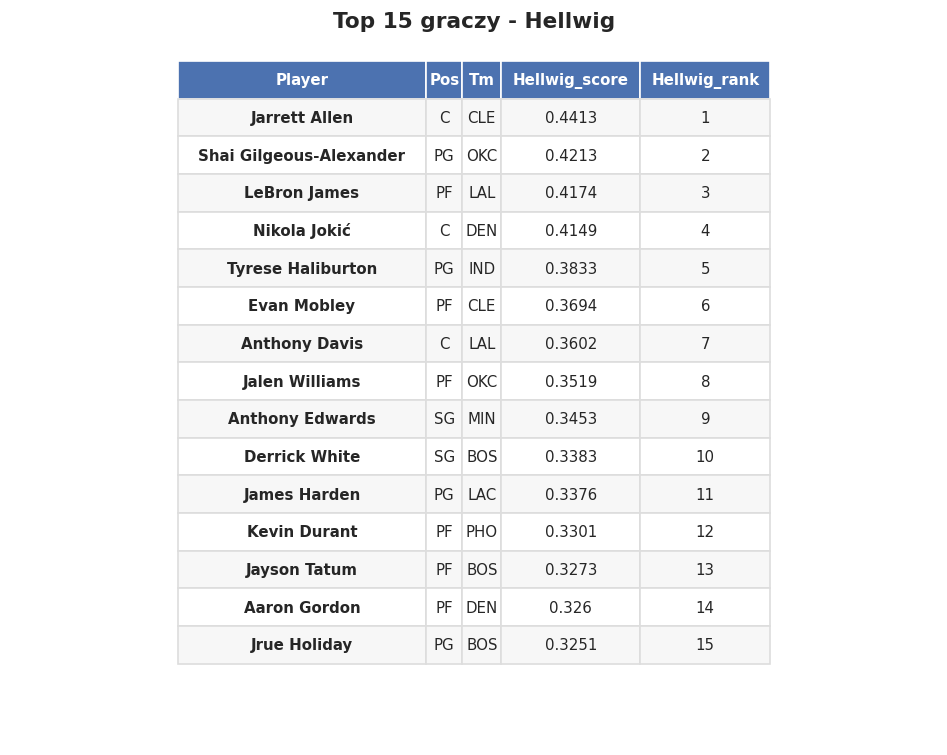

In [30]:
def ranking_hellwig(df, stimulants, destimulants):
    result = df[["Player", "Pos", "Tm"]].copy()
    all_vars = stimulants + destimulants
    n = len(df)

    # Standaryzacja z-score
    z_matrix = np.zeros((n, len(all_vars)))
    for j, var in enumerate(all_vars):
        vals = df[var].values.astype(float)
        std = vals.std(ddof=1)
        z_matrix[:, j] = (vals - vals.mean()) / std if std != 0 else 0.0

    # Wzorzec rozwoju
    z_ideal = np.zeros(len(all_vars))
    for j, var in enumerate(all_vars):
        if var in stimulants:
            z_ideal[j] = z_matrix[:, j].max()
        else:
            z_ideal[j] = z_matrix[:, j].min()

    # Odleglosci od wzorca
    d = np.sqrt(np.sum((z_matrix - z_ideal) ** 2, axis=1))

    # Wartosc graniczna
    d_0 = d.mean() + 2.0 * d.std(ddof=1)
    if d_0 == 0:
        d_0 = 1.0

    # Syntetyczny miernik
    score = 1.0 - d / d_0

    result["Hellwig_score"] = score
    result["Hellwig_rank"] = result["Hellwig_score"].rank(ascending=False, method="min").astype(int)
    result = result.sort_values("Hellwig_rank").reset_index(drop=True)
    return result

hellwig_df = ranking_hellwig(df, STIMULANTS, DESTIMULANTS)
top15_hellwig = hellwig_df[["Player", "Pos", "Tm", "Hellwig_score", "Hellwig_rank"]].head(15).copy()
top15_hellwig["Hellwig_score"] = top15_hellwig["Hellwig_score"].round(4)
render_table(top15_hellwig, title="Top 15 graczy - Hellwig", filename="tab_top15_hellwig",
             highlight_col=0)


## 6. Wyniki

### 6.1. Porównanie top graczy w trzech rankingach


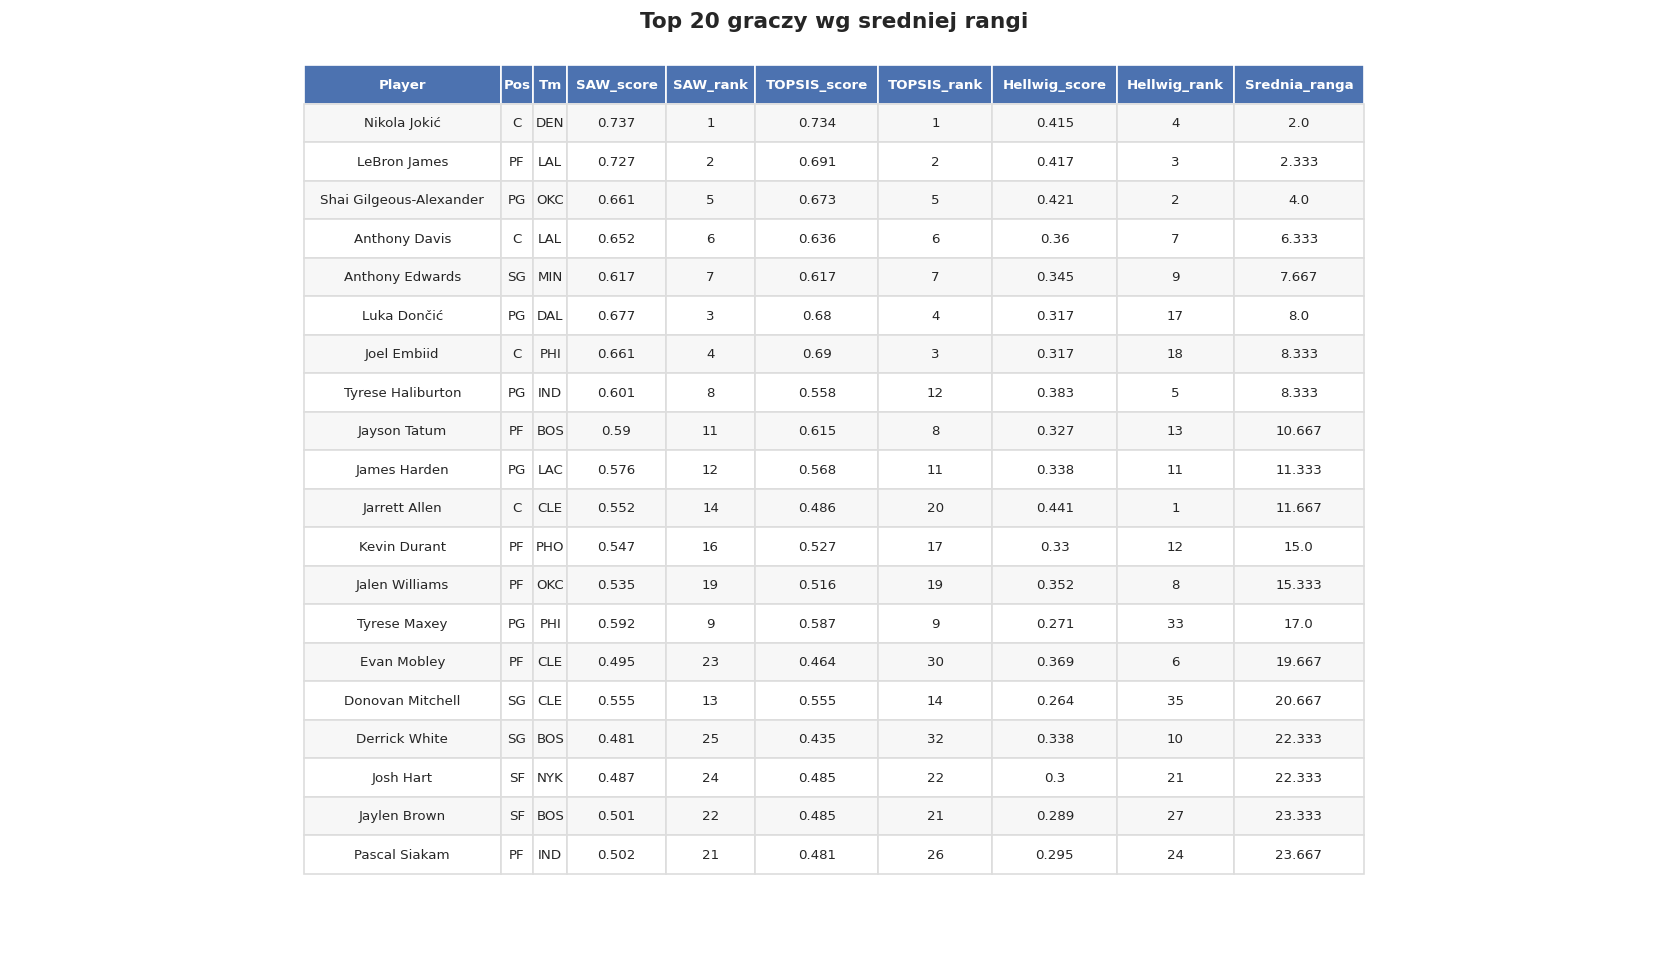

In [31]:
rankings = {"SAW": saw_df, "TOPSIS": topsis_df, "Hellwig": hellwig_df}

merged = pd.DataFrame()
for name, rdf in rankings.items():
    sub = rdf[["Player", f"{name}_score", f"{name}_rank"]].copy()
    if merged.empty:
        merged = sub
    else:
        merged = merged.merge(sub, on="Player", how="outer")

# Iformacje o zawodniku
player_info = saw_df[["Player", "Pos", "Tm"]]
merged = merged.merge(player_info, on="Player", how="left")

# Srednia ranga
rank_cols = ["SAW_rank", "TOPSIS_rank", "Hellwig_rank"]
merged["Srednia_ranga"] = merged[rank_cols].mean(axis=1)
merged = merged.sort_values("Srednia_ranga").reset_index(drop=True)

# Wyswietlenie top 20
display_cols = ["Player", "Pos", "Tm",
                "SAW_score", "SAW_rank",
                "TOPSIS_score", "TOPSIS_rank",
                "Hellwig_score", "Hellwig_rank",
                "Srednia_ranga"]

top20_cmp = merged[display_cols].head(20).copy()
for c in ["SAW_score", "TOPSIS_score", "Hellwig_score", "Srednia_ranga"]:
    top20_cmp[c] = top20_cmp[c].round(3)
render_table(top20_cmp, title="Top 20 graczy wg sredniej rangi",
             filename="tab_top20_combined", fontsize=8)


### 6.2. Wykresy słupkowe - top 15 graczy w każdym rankingu

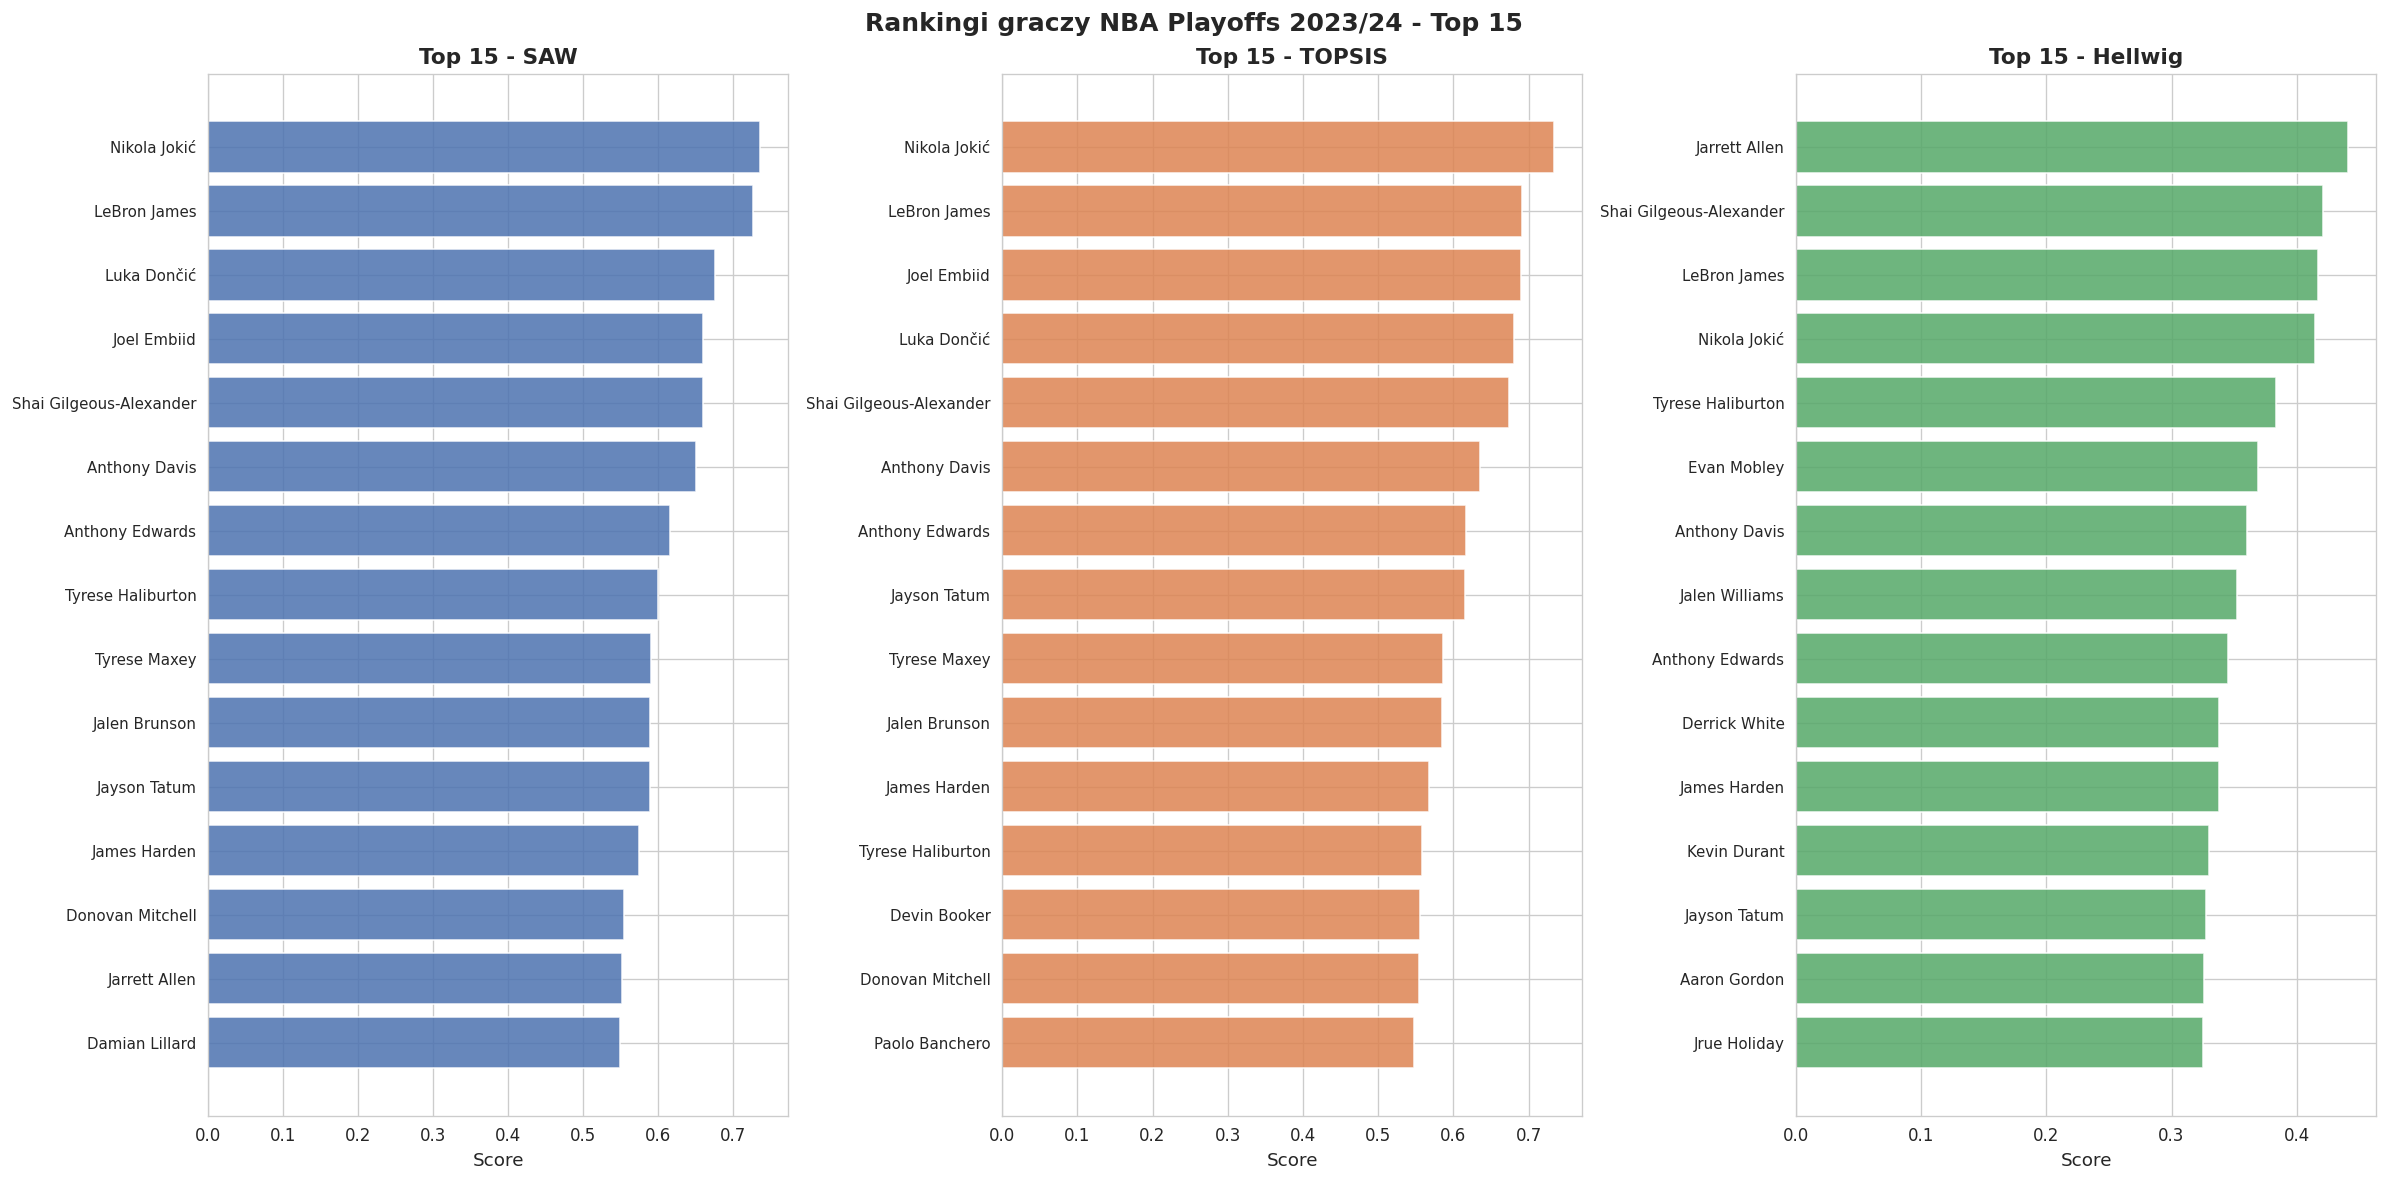

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
colors = ["#4C72B0", "#DD8452", "#55A868"]

for idx, (name, rdf) in enumerate(rankings.items()):
    ax = axes[idx]
    top = rdf.head(15).iloc[::-1]
    score_col = f"{name}_score"
    players = top["Player"].values
    scores = top[score_col].values

    bars = ax.barh(range(len(players)), scores, color=colors[idx], alpha=0.85)
    ax.set_yticks(range(len(players)))
    ax.set_yticklabels(players, fontsize=9)
    ax.set_xlabel("Score", fontsize=11)
    ax.set_title(f"Top 15 - {name}", fontsize=13, fontweight="bold")

fig.suptitle("Rankingi graczy NBA Playoffs 2023/24 - Top 15",
             fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()


### 6.3. Bump chart - porównanie pozycji graczy między rankingami

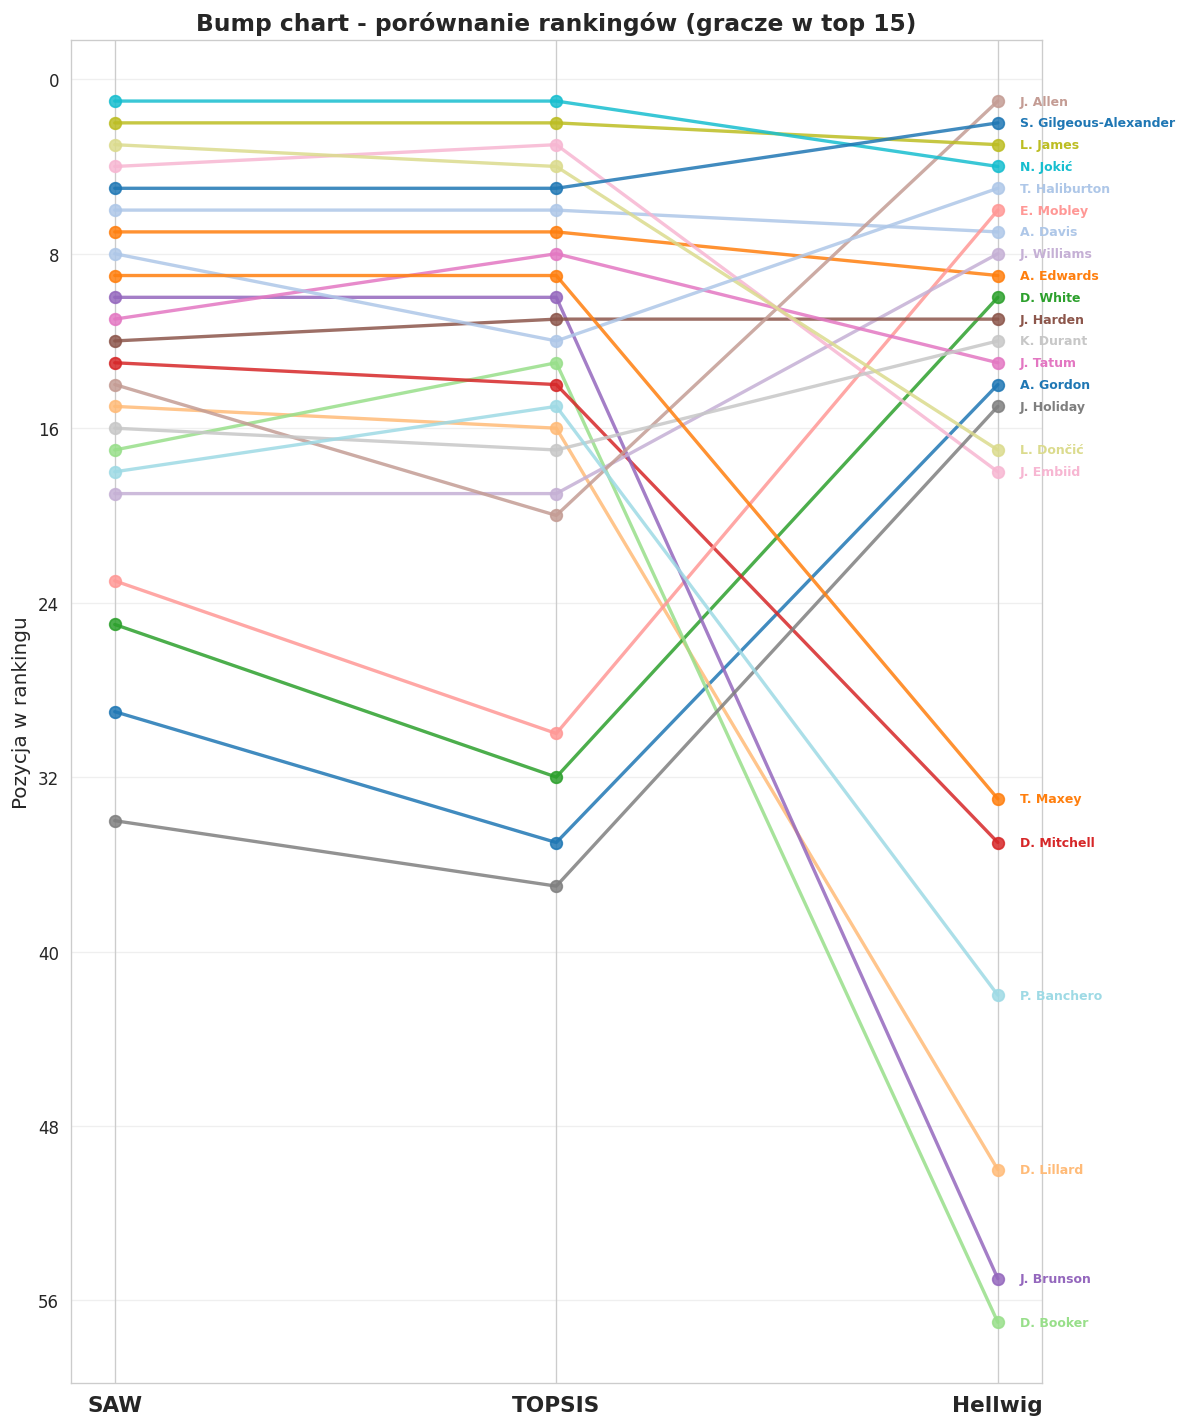

In [33]:
method_names = list(rankings.keys())
TOP_N_BUMP = 15

all_ranks = {}
for name, rdf in rankings.items():
    for _, row in rdf.iterrows():
        player = row["Player"]
        if player not in all_ranks:
            all_ranks[player] = {}
        all_ranks[player][name] = row[f"{name}_rank"]

top_players = set()
for name, rdf in rankings.items():
    top_players.update(rdf.head(TOP_N_BUMP)["Player"].values)

fig, ax = plt.subplots(figsize=(10, 12))
cmap = plt.get_cmap("tab20")
player_list = sorted(top_players)

for i, player in enumerate(player_list):
    if player not in all_ranks:
        continue
    ranks_for_player = all_ranks[player]
    xs, ys = [], []
    for j, method in enumerate(method_names):
        if method in ranks_for_player:
            xs.append(j)
            ys.append(ranks_for_player[method])

    color = cmap(i % 20)
    ax.plot(xs, ys, marker="o", color=color, linewidth=2, markersize=7, alpha=0.85)

    if ys:
        parts = player.split()
        short = parts[0][0] + ". " + " ".join(parts[1:]) if len(parts) >= 2 else player
        ax.annotate(short, (xs[-1] + 0.05, ys[-1]),
                    fontsize=7.5, va="center", color=color, fontweight="bold")

ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, fontsize=13, fontweight="bold")
ax.set_ylabel("Pozycja w rankingu", fontsize=12)
ax.set_title(f"Bump chart - porównanie rankingów (gracze w top {TOP_N_BUMP})",
             fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


### 6.4. Zgodność rankingów - korelacja Spearmana i tau Kendalla

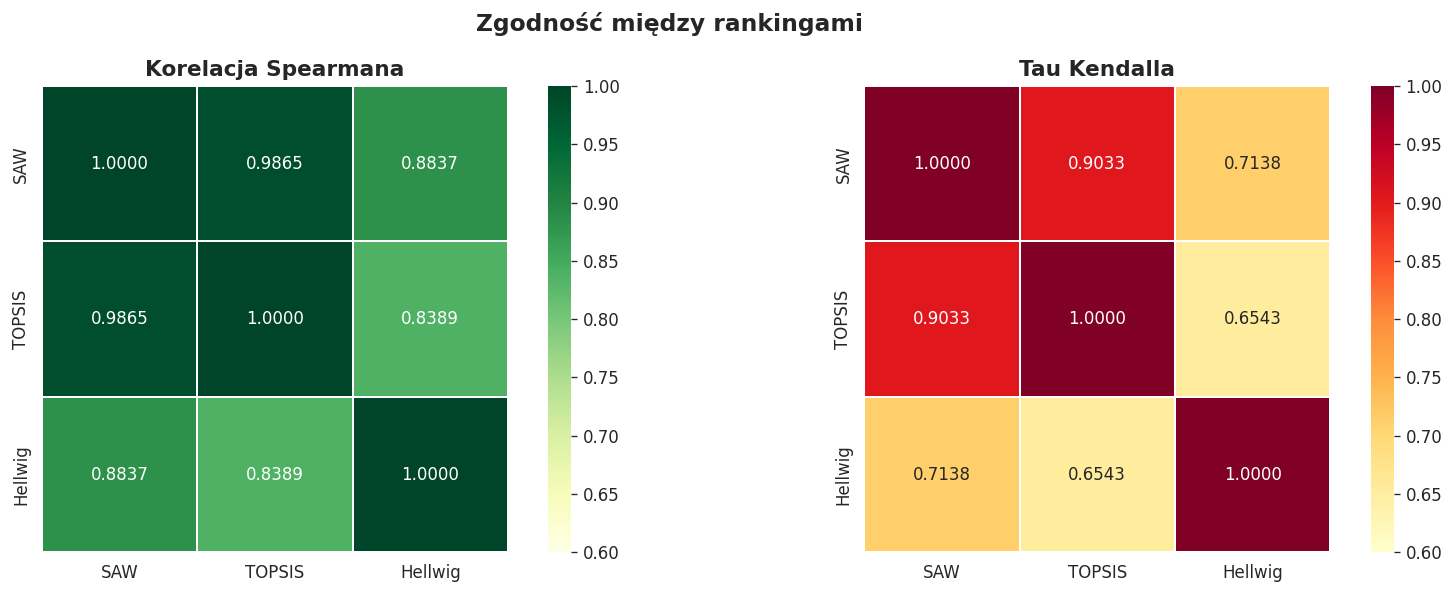

In [34]:
# Korelacja Spearmana i tau Kendalla
method_names = ["SAW", "TOPSIS", "Hellwig"]
rank_cols = [f"{m}_rank" for m in method_names]

spearman_matrix = pd.DataFrame(index=method_names, columns=method_names, dtype=float)
kendall_matrix = pd.DataFrame(index=method_names, columns=method_names, dtype=float)

for m1 in method_names:
    for m2 in method_names:
        r1 = merged[f"{m1}_rank"].values
        r2 = merged[f"{m2}_rank"].values
        rho, _ = sp_stats.spearmanr(r1, r2)
        tau, _ = sp_stats.kendalltau(r1, r2)
        spearman_matrix.loc[m1, m2] = round(rho, 4)
        kendall_matrix.loc[m1, m2] = round(tau, 4)

# Heatmapa korelacji Spearmana
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, matrix, title, cmap_name in [
    (axes[0], spearman_matrix, "Korelacja Spearmana", "YlGn"),
    (axes[1], kendall_matrix, "Tau Kendalla", "YlOrRd")
]:
    vals = matrix.values.astype(float)
    sns.heatmap(vals, annot=True, fmt=".4f", cmap=cmap_name,
                xticklabels=matrix.columns, yticklabels=matrix.index,
                vmin=0.6, vmax=1.0, square=True, linewidths=1, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold")

fig.suptitle("Zgodność między rankingami", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


### 6.5. Wykresy rozrzutu rang

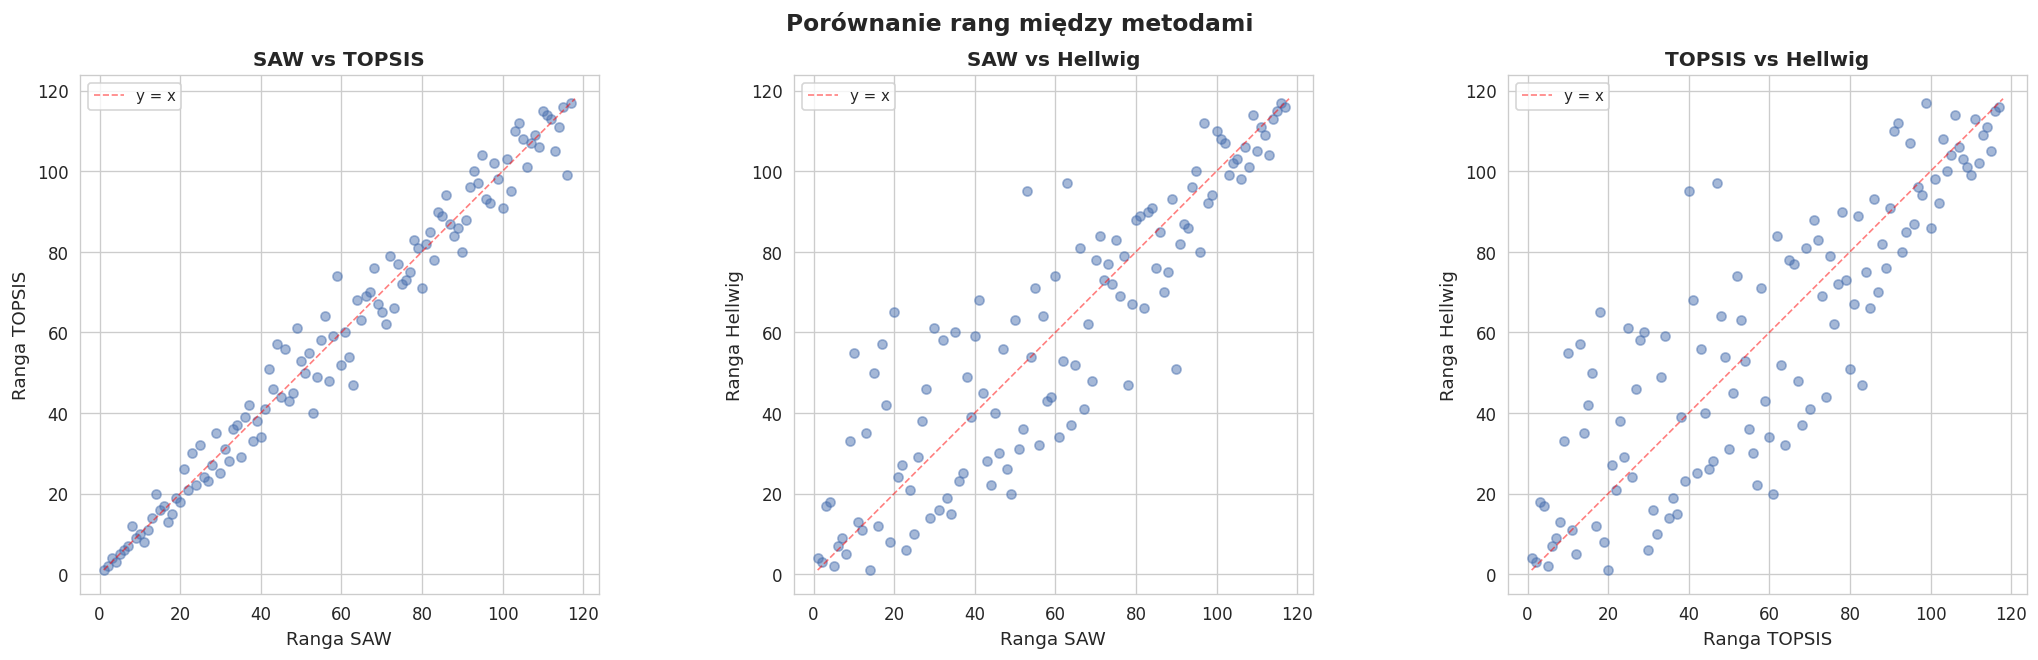

In [35]:
pairs = [("SAW", "TOPSIS"), ("SAW", "Hellwig"), ("TOPSIS", "Hellwig")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for idx, (m1, m2) in enumerate(pairs):
    ax = axes[idx]
    x = merged[f"{m1}_rank"].values
    y = merged[f"{m2}_rank"].values

    ax.scatter(x, y, alpha=0.5, s=30, c="#4C72B0")
    lim = max(x.max(), y.max()) + 1
    ax.plot([1, lim], [1, lim], "r--", alpha=0.5, linewidth=1, label="y = x")
    ax.set_xlabel(f"Ranga {m1}", fontsize=11)
    ax.set_ylabel(f"Ranga {m2}", fontsize=11)
    ax.set_title(f"{m1} vs {m2}", fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.legend(fontsize=9)

fig.suptitle("Porównanie rang między metodami", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


**Interpretacja zgodności rankingów:**

| Para metod | ρ Spearmana | τ Kendalla | Interpretacja |
|-----------|------------|------------|---------------|
| SAW <=> TOPSIS | 0,987 | 0,903 | Bardzo wysoka zgodność |
| SAW <=> Hellwig | 0,884 | 0,714 | Wysoka zgodność |
| TOPSIS <=> Hellwig | 0,839 | 0,654 | Umiarkowanie wysoka zgodność |

- **SAW i TOPSIS** dają niemal identyczne wyniki (ρ = 0,987). Obie metody stosują te same wagi eksperckie - różnią się jedynie sposobem normalizacji (min-max vs. wektorowa).
- **Hellwig** daje nieco odmienne wyniki, ponieważ **nie stosuje wag eksperckich** - traktuje wszystkie zmienne równoważnie. W efekcie nagradza graczy o **zbalansowanym profilu** (np. Jarrett Allen: wysokie TRB, wysokie eFG%, niskie TOV, niskie PF).
- SAW i TOPSIS preferują graczy dominujących w wysoko ważonych zmiennych (PTS, AST), co tłumaczy dominację Jokića i LeBrona.


### 6.6. Analiza wybranych graczy — największe różnice między metodami

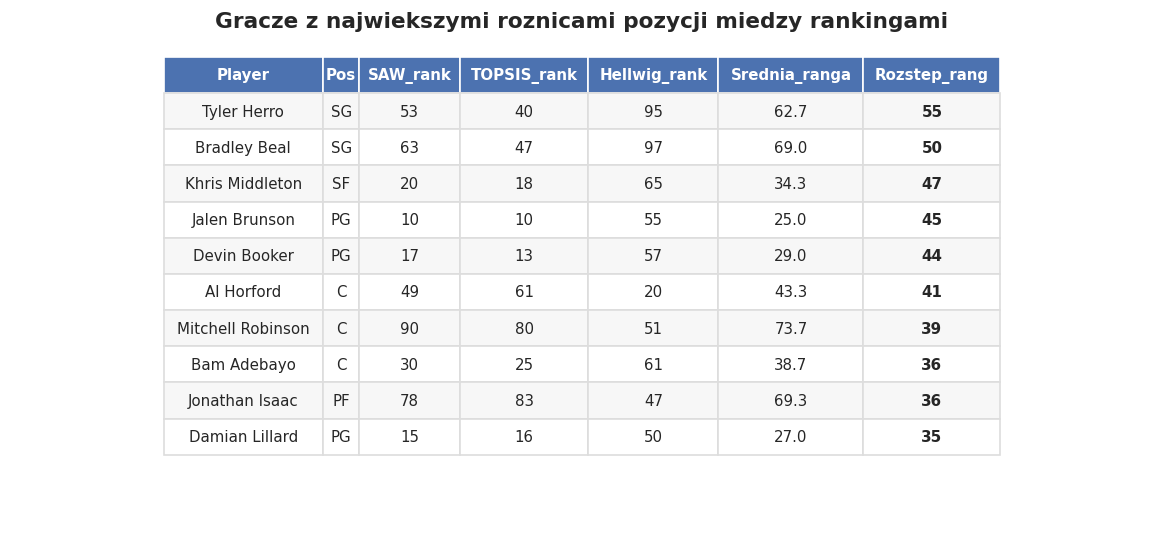

In [36]:
# Gracze z najwiekszymi roznicami miedzy rankingami
merged["Rozstep_rang"] = merged[rank_cols].max(axis=1) - merged[rank_cols].min(axis=1)

biggest_diff = merged.nlargest(10, "Rozstep_rang")
diff_display = biggest_diff[["Player", "Pos", "SAW_rank", "TOPSIS_rank", "Hellwig_rank",
                              "Srednia_ranga", "Rozstep_rang"]].copy()
diff_display["Srednia_ranga"] = diff_display["Srednia_ranga"].round(1)
render_table(diff_display, title="Gracze z najwiekszymi roznicami pozycji miedzy rankingami",
             filename="tab_biggest_diff", highlight_col=6)


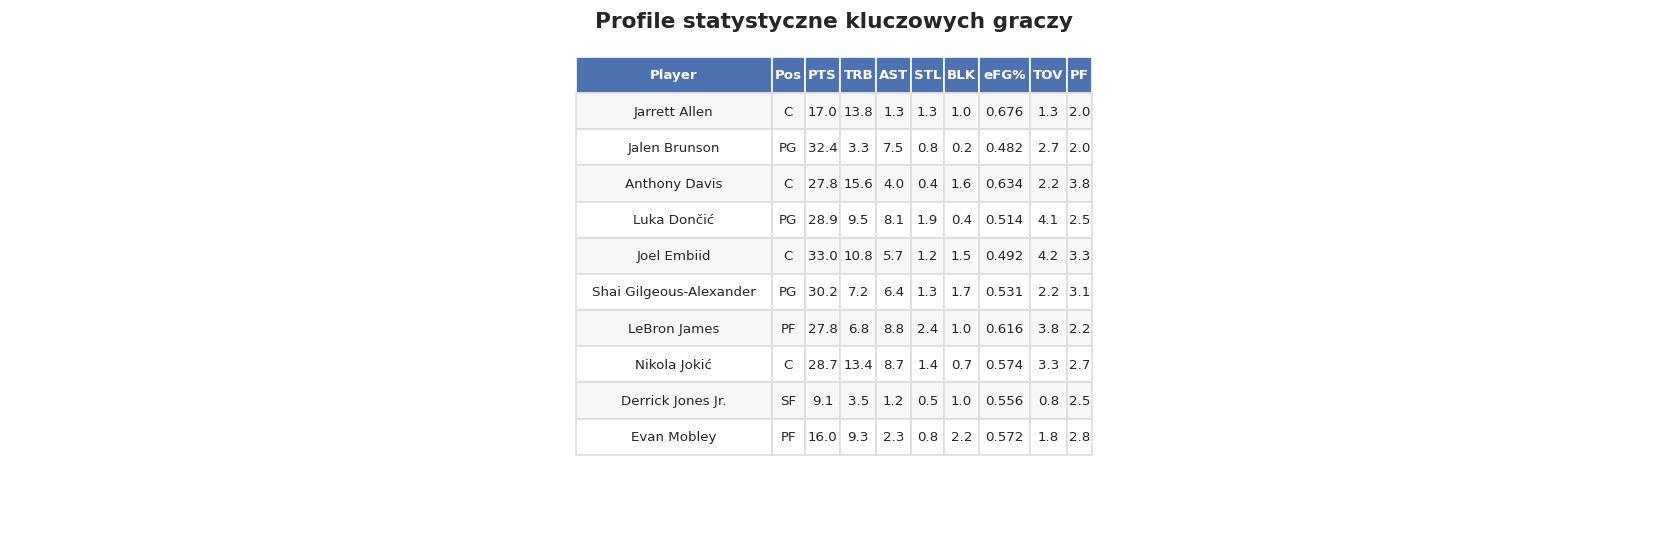

In [37]:
# Analiza profilu kluczowych graczy
key_players = ["Nikola Joki\u0107", "Jarrett Allen", "Luka Don\u010di\u0107",
               "LeBron James", "Shai Gilgeous-Alexander", "Jalen Brunson",
               "Anthony Davis", "Evan Mobley", "Derrick White", "Joel Embiid"]

available = df["Player"].tolist()
matched = []
for kp in key_players:
    for ap in available:
        if ap.startswith(kp[:5]) or kp.startswith(ap[:5]):
            matched.append(ap)
            break

mask = df["Player"].isin(matched)
if mask.sum() > 0:
    profile = df.loc[mask, ["Player", "Pos"] + ALL_VARIABLES].copy()
else:
    top10_names = merged.head(10)["Player"].tolist()
    profile = df[df["Player"].isin(top10_names)][["Player", "Pos"] + ALL_VARIABLES].copy()

# Zaokraglenie wartosci aby byly bardziej czytelne
for c in ALL_VARIABLES:
    profile[c] = profile[c].round(3)

render_table(profile, title="Profile statystyczne kluczowych graczy",
             filename="tab_key_player_profiles", fontsize=8)


**Analiza wybranych przypadków:**

1. **Jarrett Allen** - #1 w Hellwigu, ale #14 w SAW i #20 w TOPSIS. Hellwig nagradza jego *zbalansowany profil*: wysokie zbiórki (13,8/mecz), wysoka eFG% i bardzo niskie straty. Bez wag, te cechy dają mu przewagę. W SAW/TOPSIS niska waga TOV i PF (po 0,05) minimalizuje jego "czystość" gry, a średnia liczba punktów (14,8) obniża pozycję przy wadze PTS = 0,25.

2. **Luka Dončić** - #3 w SAW, #4 w TOPSIS, ale #17 w Hellwigu. Dončić dominuje w punktach i asystach (zmienne z najwyższymi wagami), co podnosi go w SAW/TOPSIS. Jednak jego **4,6 strat/mecz** (najwyższe w zbiorze) i wysokie faule obniżają go w Hellwigu, który równoważnie traktuje wszystkie zmienne.

3. **Joel Embiid** - #4 w SAW, #3 w TOPSIS, ale #18 w Hellwigu. Podobna sytuacja - 33 pkt/mecz to najwyższy wynik w zbiorze, ale straty (4,3/mecz) i faule (2,5/mecz) silnie obniżają Hellwiga.

4. **Jalen Brunson** - #10 w SAW, #10 w TOPSIS, ale #55 w Hellwigu. Najskrajniejszy przypadek - mocny strzelec i kreator, ale Hellwig karze go za stosunkowo niskie zbiórki, bloki i eFG% przy jednoczesnych stratach.


### 6.7. Rozkład pozycji w top 20 każdego rankingu

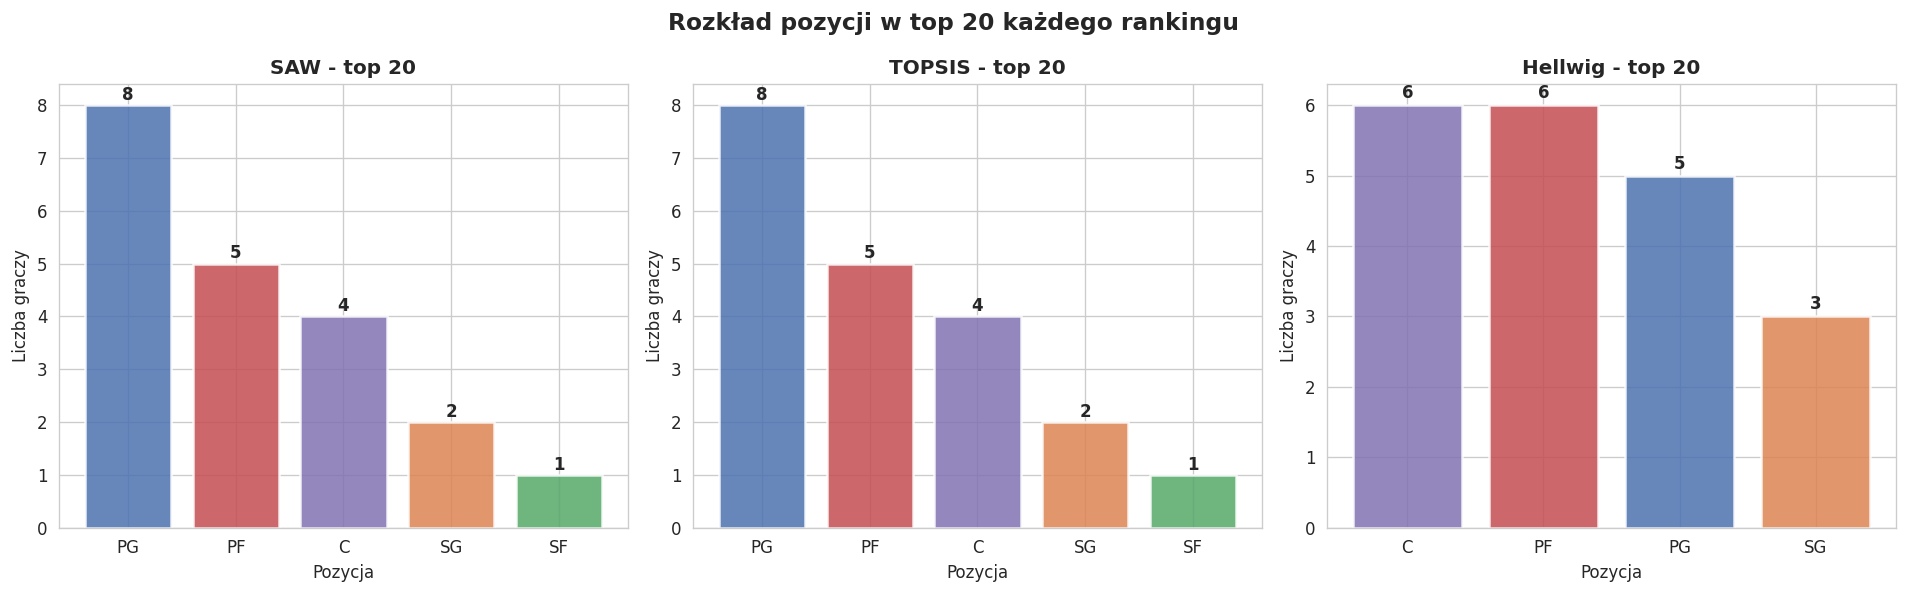

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_pos = {"PG": "#4C72B0", "SG": "#DD8452", "SF": "#55A868", "PF": "#C44E52", "C": "#8172B3"}

for idx, (name, rdf) in enumerate(rankings.items()):
    ax = axes[idx]
    top20 = rdf.head(20)
    pos_counts = top20["Pos"].value_counts()
    bars = ax.bar(pos_counts.index, pos_counts.values,
                  color=[colors_pos.get(p, "gray") for p in pos_counts.index],
                  alpha=0.85, edgecolor="white", linewidth=1.5)
    ax.set_title(f"{name} - top 20", fontsize=12, fontweight="bold")
    ax.set_ylabel("Liczba graczy")
    ax.set_xlabel("Pozycja")
    for bar, val in zip(bars, pos_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Rozkład pozycji w top 20 każdego rankingu", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


### 6.8. Ranking zagregowany (średnia ważona trzech metod)

Aby uzyskać jeden końcowy ranking, uśredniamy **znormalizowane score'y** trzech metod
z równymi wagami (1/3 każda). Normalizacja min-max score'ów jest konieczna, ponieważ
zakresy wartości różnią się między metodami (np. SAW ∈ [0.17, 0.74], Hellwig ∈ [-0.08, 0.44]).

$$S_i^{AGR} = \frac{1}{3} \cdot \hat{S}_i^{SAW} + \frac{1}{3} \cdot \hat{S}_i^{TOPSIS} + \frac{1}{3} \cdot \hat{S}_i^{Hellwig}$$

gdzie $\hat{S}_i^{(m)} = \frac{S_i^{(m)} - S_{min}^{(m)}}{S_{max}^{(m)} - S_{min}^{(m)}}$ — normalizacja min-max score'u metody $m$.


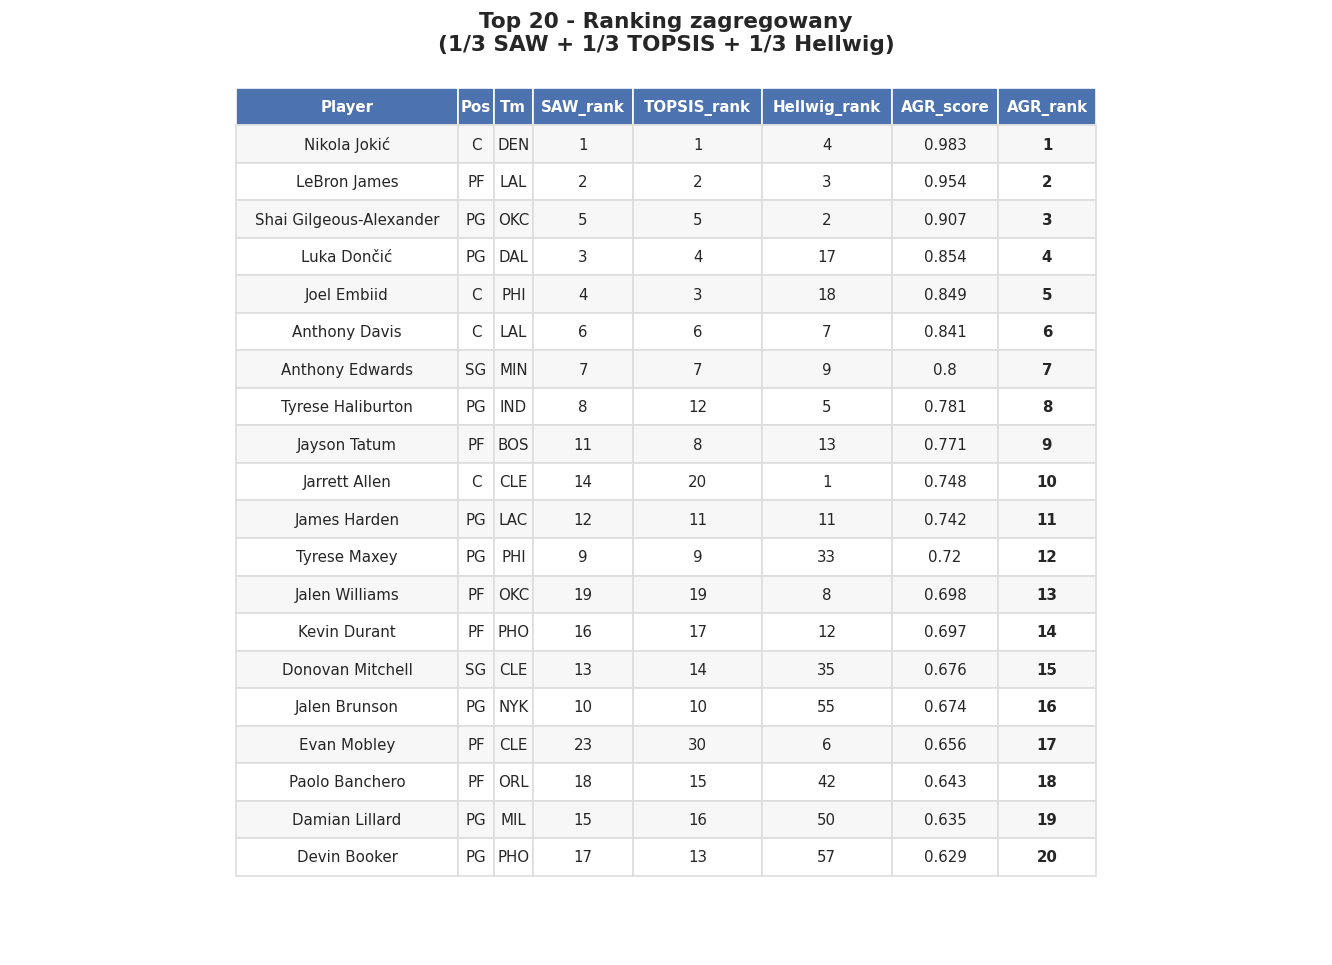

In [39]:
# Ranking zagregowany: srednia wazona 1/3 z trzech metod
for method in ["SAW", "TOPSIS", "Hellwig"]:
    col = f"{method}_score"
    s_min = merged[col].min()
    s_max = merged[col].max()
    merged[f"{method}_score_norm"] = (merged[col] - s_min) / (s_max - s_min)

# Srednia, kazdda metoda jest sobie rowna
merged["AGR_score"] = (
    (1/3) * merged["SAW_score_norm"] +
    (1/3) * merged["TOPSIS_score_norm"] +
    (1/3) * merged["Hellwig_score_norm"]
)

merged["AGR_rank"] = merged["AGR_score"].rank(ascending=False, method="min").astype(int)
merged = merged.sort_values("AGR_rank").reset_index(drop=True)

agr_cols = ["Player", "Pos", "Tm",
            "SAW_rank", "TOPSIS_rank", "Hellwig_rank",
            "AGR_score", "AGR_rank"]
top20_agr_tbl = merged[agr_cols].head(20).copy()
top20_agr_tbl["AGR_score"] = top20_agr_tbl["AGR_score"].round(3)
render_table(top20_agr_tbl,
             title="Top 20 - Ranking zagregowany\n(1/3 SAW + 1/3 TOPSIS + 1/3 Hellwig)",
             filename="tab_top20_aggregated", highlight_col=7)


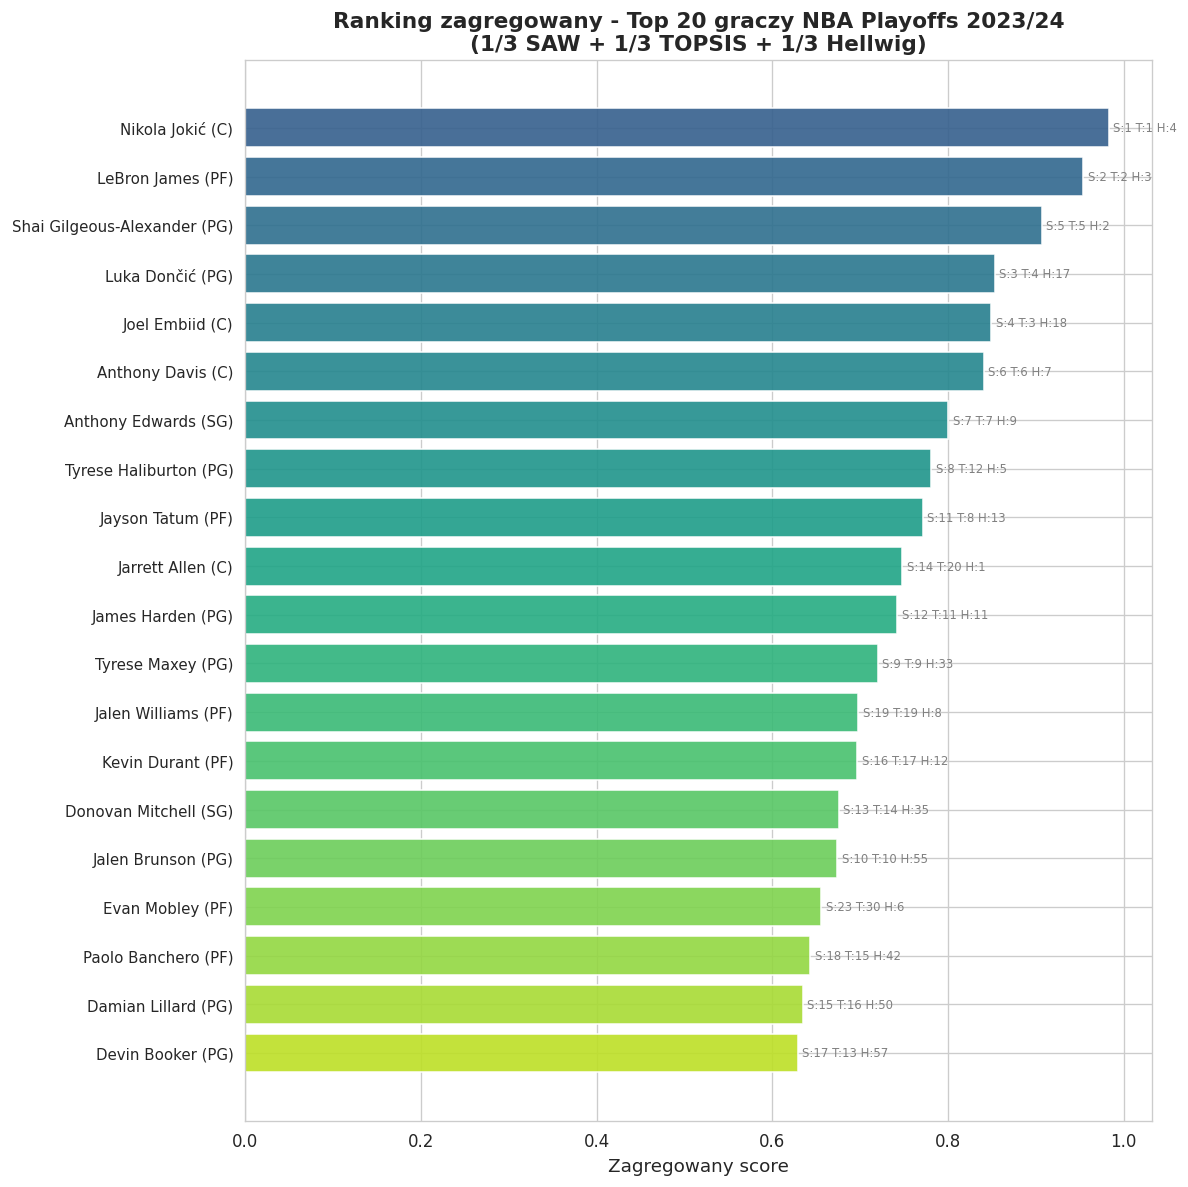

In [40]:
# Barplot top 20 zagregowany
fig, ax = plt.subplots(figsize=(10, 10))
top20_agr = merged.head(20).iloc[::-1]

colors_agr = plt.cm.viridis(np.linspace(0.3, 0.9, 20))[::-1]
bars = ax.barh(range(20), top20_agr["AGR_score"].values, color=colors_agr, alpha=0.9)
ax.set_yticks(range(20))
labels = [f"{row['Player']} ({row['Pos']})" for _, row in top20_agr.iterrows()]
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Zagregowany score", fontsize=11)
ax.set_title("Ranking zagregowany - Top 20 graczy NBA Playoffs 2023/24\n(1/3 SAW + 1/3 TOPSIS + 1/3 Hellwig)",
             fontsize=13, fontweight="bold")

# Wypisanie pozycji w poszczegolnym rankingu
for i, (_, row) in enumerate(top20_agr.iterrows()):
    ax.text(row["AGR_score"] + 0.005, i,
            f"S:{int(row['SAW_rank'])} T:{int(row['TOPSIS_rank'])} H:{int(row['Hellwig_rank'])}",
            va="center", fontsize=7, color="gray")

fig.tight_layout()
plt.show()


In [41]:
print("=== Korelacja Spearmana rankingu zagregowanego z poszczególnymi metodami ===\n")
for method in ["SAW", "TOPSIS", "Hellwig"]:
    rho, pval = sp_stats.spearmanr(merged["AGR_rank"], merged[f"{method}_rank"])
    print(f"  AGR vs {method}: rho = {rho:.4f} (p = {pval:.2e})")


=== Korelacja Spearmana rankingu zagregowanego z poszczególnymi metodami ===

  AGR vs SAW: rho = 0.9930 (p = 1.12e-108)
  AGR vs TOPSIS: rho = 0.9792 (p = 1.61e-81)
  AGR vs Hellwig: rho = 0.9218 (p = 3.86e-49)


**Komentarz:** Ranking zagregowany łączy informację z trzech różnych perspektyw metodologicznych.
Dzięki równym wagom (1/3) żadna metoda nie dominuje. Normalizacja min-max score'ów zapewnia,
że każda metoda ma porównywalny wpływ na wynik końcowy niezależnie od zakresu wartości.


### 6.9. Ranking top graczy dla każdej pozycji

Koszykówka NBA wyróżnia 5 pozycji o różnych rolach na parkiecie:
- **PG** (Point Guard) - rozgrywający, kreator gry
- **SG** (Shooting Guard) - rzucający obrońca
- **SF** (Small Forward) - niski skrzydłowy
- **PF** (Power Forward) - silny skrzydłowy
- **C** (Center) - środkowy

Poniżej przedstawiamy top 5 graczy na każdej pozycji wg rankingu zagregowanego.


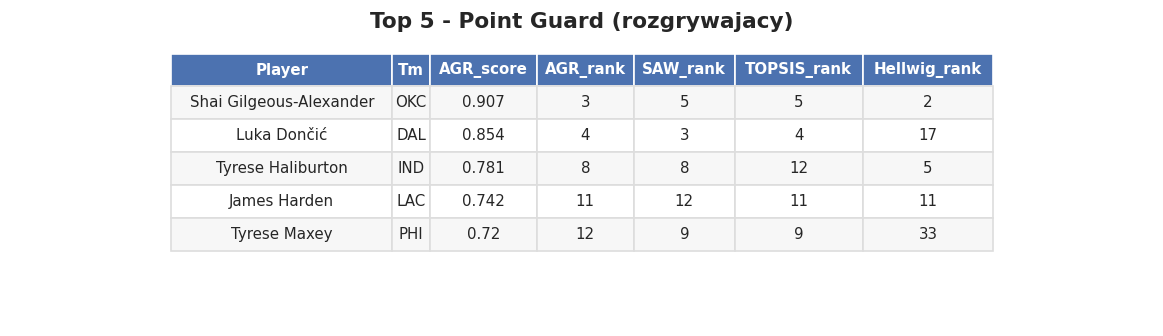

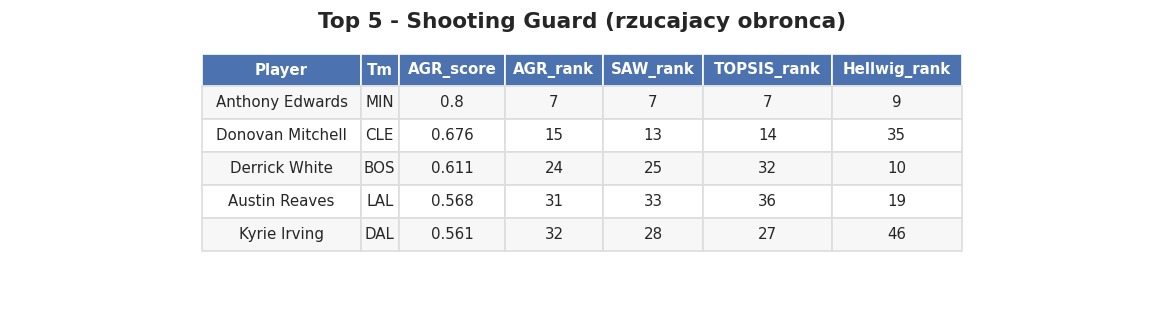

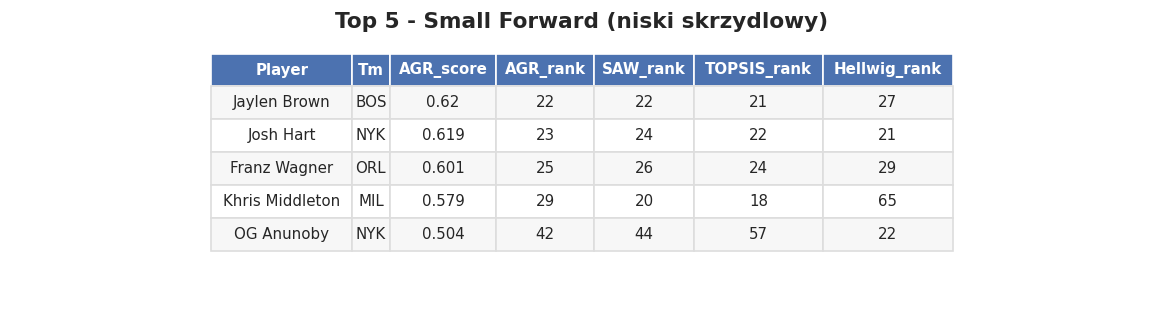

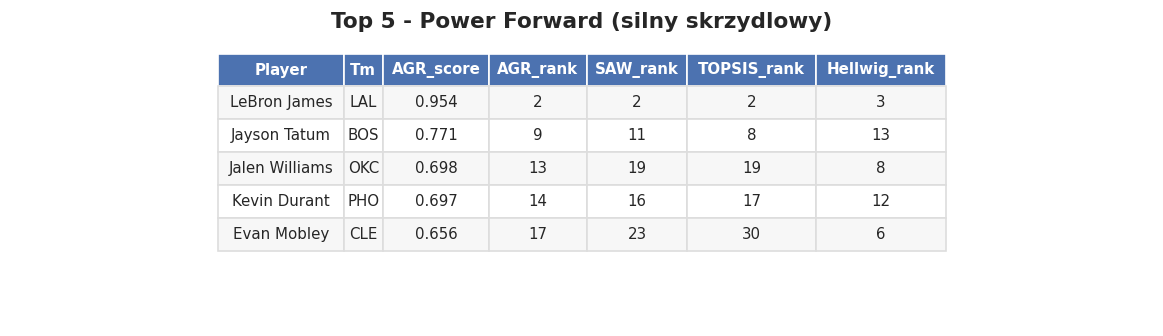

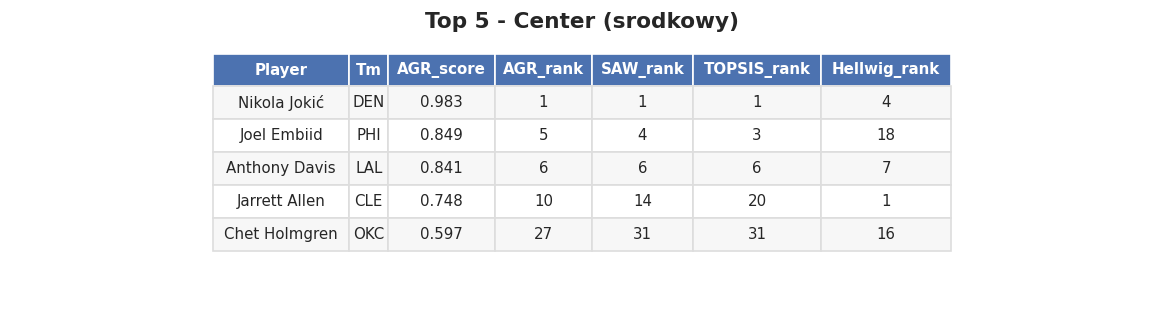

In [42]:
# Top 5 graczy na kazda pozycje wg rankingu zagregowanego
positions = ["PG", "SG", "SF", "PF", "C"]
pos_names = {
    "PG": "Point Guard (rozgrywajacy)",
    "SG": "Shooting Guard (rzucajacy obronca)",
    "SF": "Small Forward (niski skrzydlowy)",
    "PF": "Power Forward (silny skrzydlowy)",
    "C": "Center (srodkowy)",
}

pos_top5 = {}
for pos in positions:
    pos_df = merged[merged["Pos"] == pos].nsmallest(5, "AGR_rank")
    pos_top5[pos] = pos_df
    display_cols = ["Player", "Tm", "AGR_score", "AGR_rank",
                    "SAW_rank", "TOPSIS_rank", "Hellwig_rank"]
    tbl = pos_df[display_cols].copy()
    tbl["AGR_score"] = tbl["AGR_score"].round(3)
    render_table(tbl, title=f"Top 5 - {pos_names[pos]}",
                 filename=f"tab_top5_{pos}")


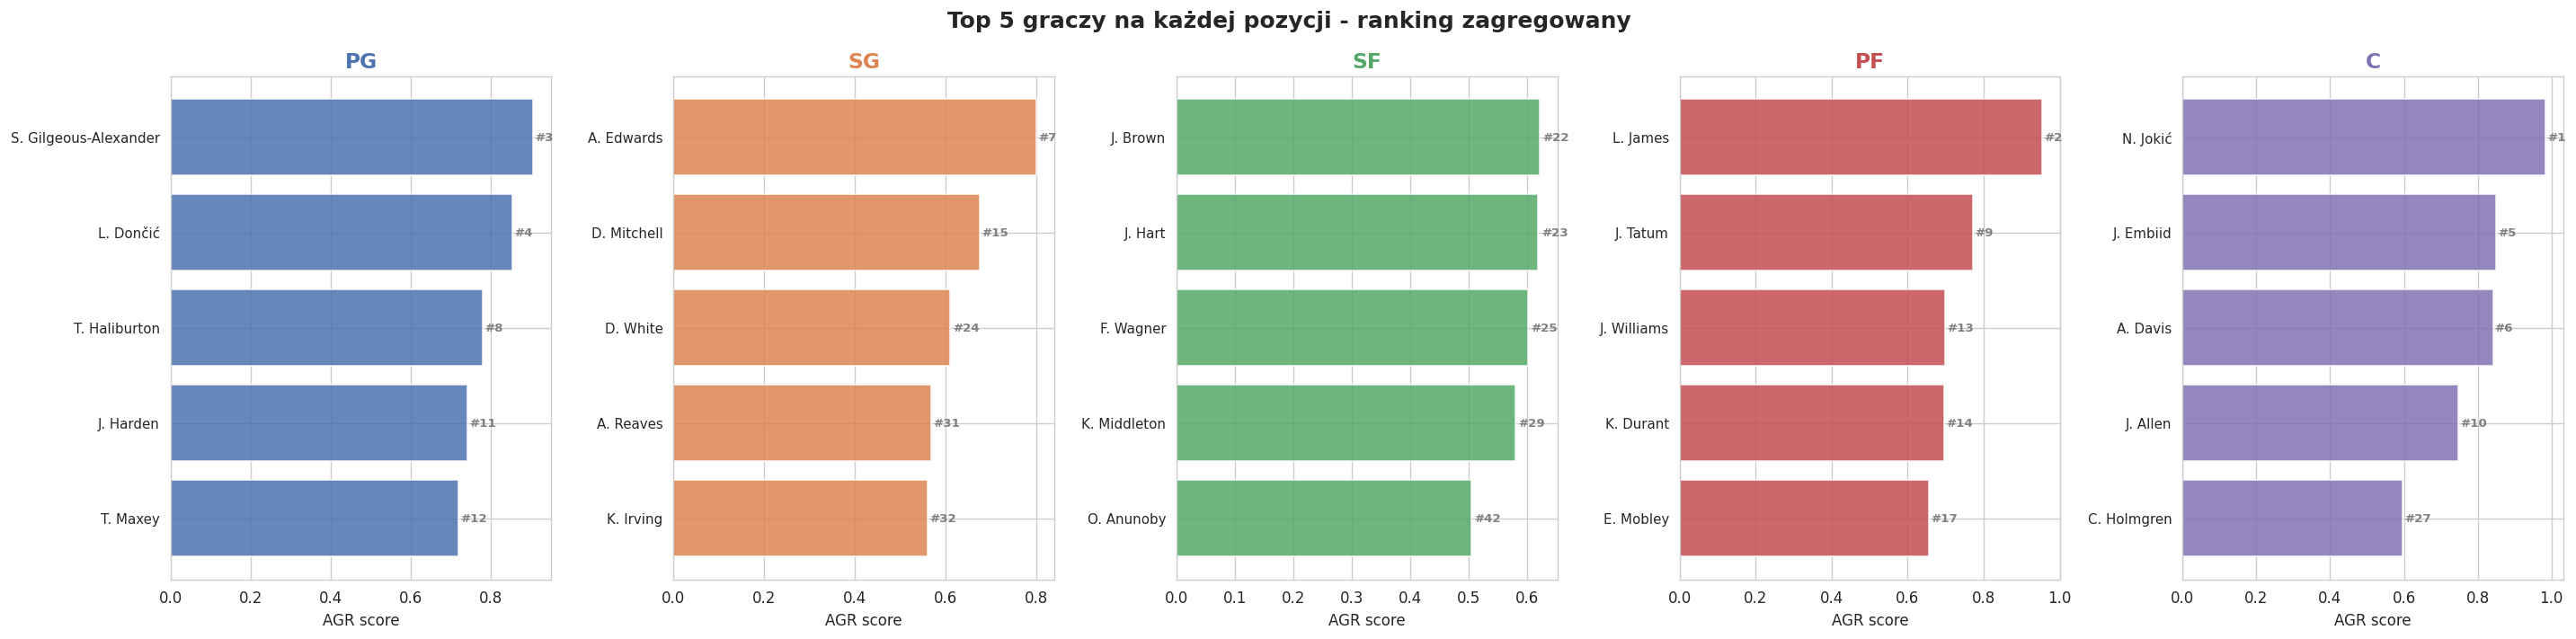

In [43]:
# Wizualizacja: top 5 na kazda pozycje
fig, axes = plt.subplots(1, 5, figsize=(24, 6), sharey=False)
colors_pos = {"PG": "#4C72B0", "SG": "#DD8452", "SF": "#55A868", "PF": "#C44E52", "C": "#8172B3"}

for idx, pos in enumerate(positions):
    ax = axes[idx]
    top5 = pos_top5[pos].iloc[::-1]

    players = top5["Player"].values
    scores = top5["AGR_score"].values
    color = colors_pos[pos]

    bars = ax.barh(range(len(players)), scores, color=color, alpha=0.85)
    ax.set_yticks(range(len(players)))
    # Skrocenie imion zawodnikow
    short_names = []
    for p in players:
        parts = p.split()
        if len(parts) >= 2:
            short_names.append(parts[0][0] + ". " + " ".join(parts[1:]))
        else:
            short_names.append(p)
    ax.set_yticklabels(short_names, fontsize=9)
    ax.set_xlabel("AGR score", fontsize=10)
    ax.set_title(f"{pos}", fontsize=14, fontweight="bold", color=color)

    for i, (_, row) in enumerate(top5.iterrows()):
        ax.text(scores[i] + 0.005, i, f"#{int(row['AGR_rank'])}",
                va="center", fontsize=8, fontweight="bold", color="gray")

fig.suptitle("Top 5 graczy na każdej pozycji - ranking zagregowany",
             fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()


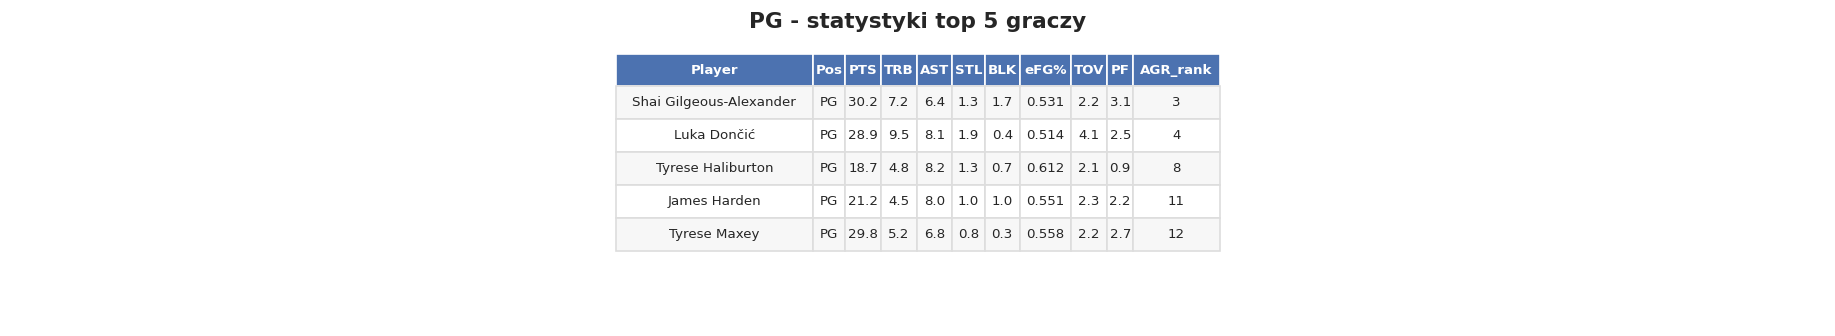

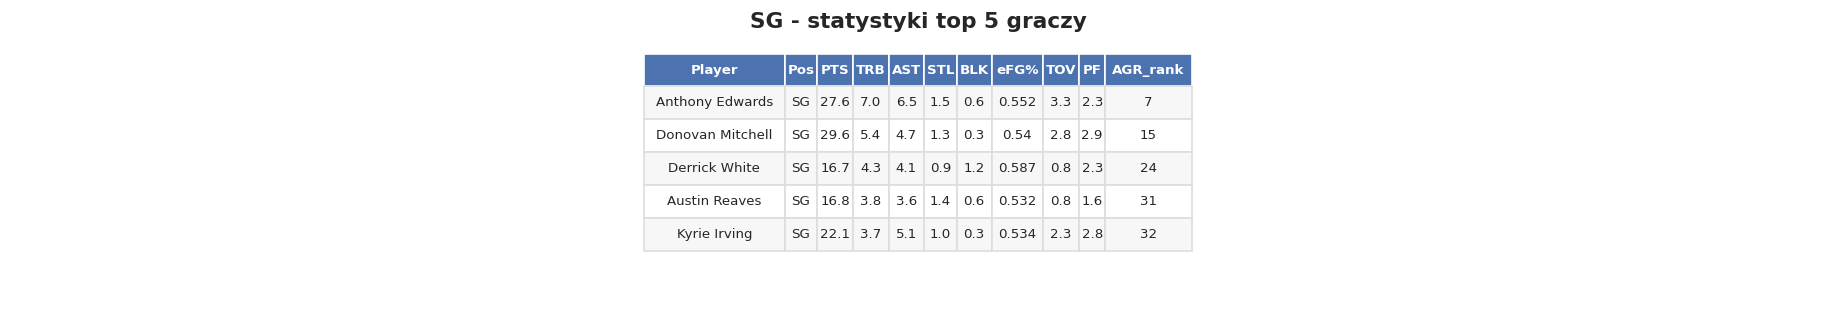

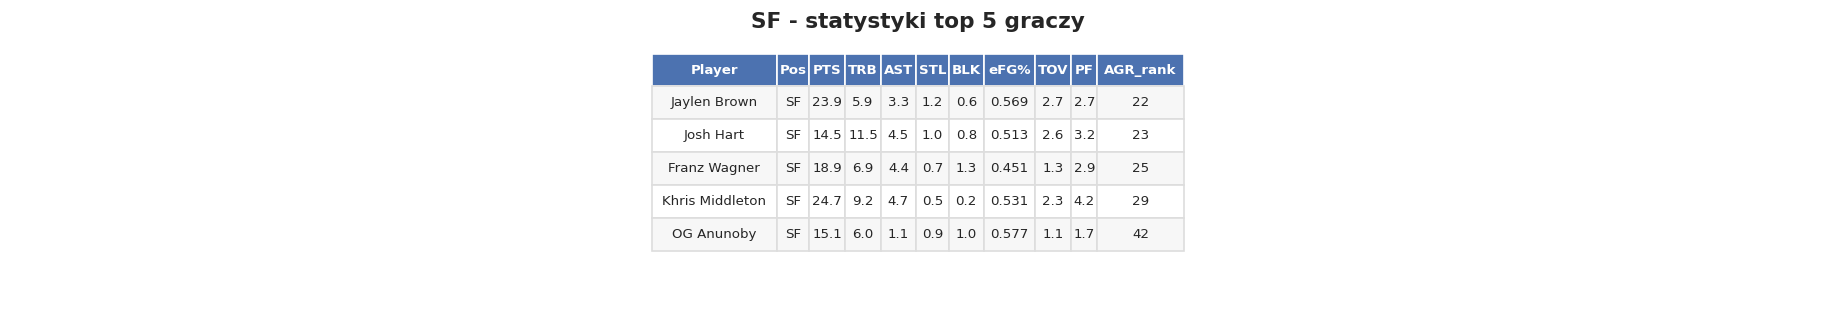

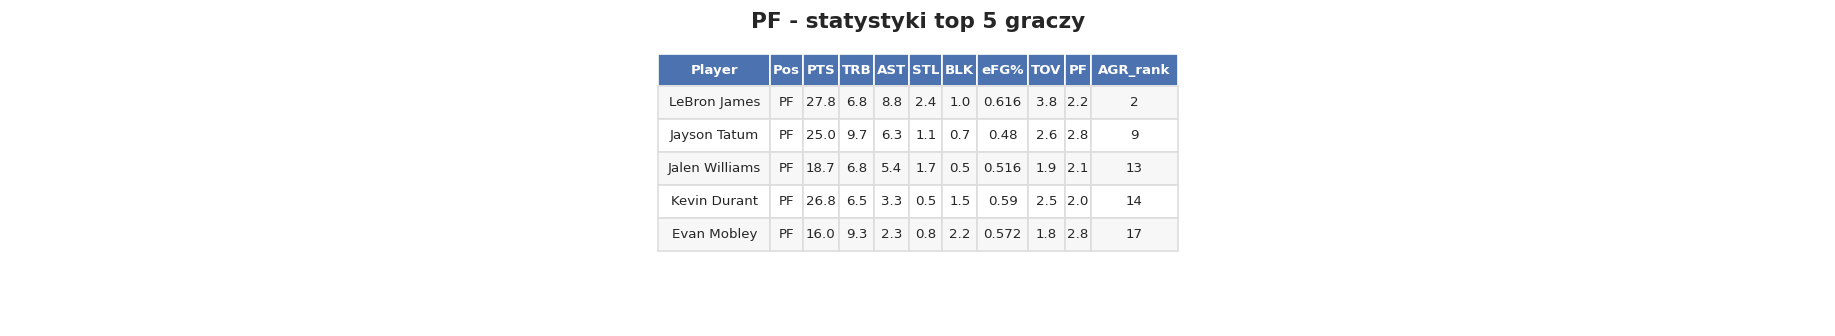

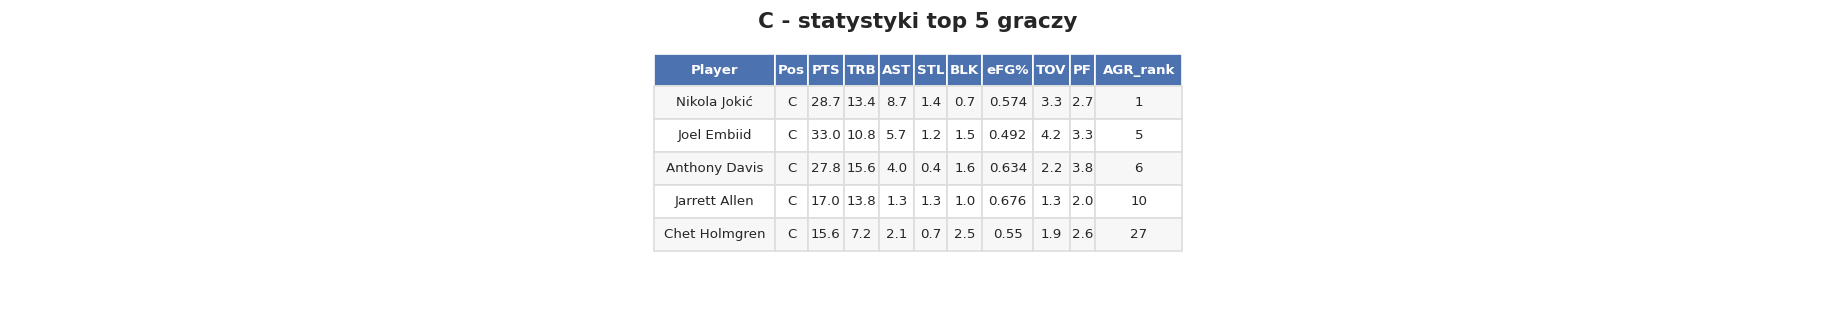

In [44]:
# Tabela zbiorcza: top 5 per pozycja z kluczowymi statystykami
for pos in positions:
    top5_names = pos_top5[pos]["Player"].tolist()
    pos_stats = df[df["Player"].isin(top5_names)][["Player", "Pos"] + ALL_VARIABLES].copy()
    agr_info = merged[merged["Player"].isin(top5_names)][["Player", "AGR_rank"]].copy()
    pos_stats = pos_stats.merge(agr_info, on="Player")
    pos_stats = pos_stats.sort_values("AGR_rank")
    for c in ALL_VARIABLES:
        pos_stats[c] = pos_stats[c].round(3)
    render_table(pos_stats, title=f"{pos} - statystyki top 5 graczy",
                 filename=f"tab_top5_stats_{pos}", fontsize=8)


**Obserwacje z rankingu per pozycja:**

- **PG:** Dominacja kreatorów gry - Shai Gilgeous-Alexander, LeBron James (klasyfikowany jako PF w danych, ale wielu PG jest w top ogólnym). Haliburton wyróżnia się na tle Brunson/Maxey dzięki lepszej efektywności (eFG%) i mniejszej liczbie strat.
- **SG:** Anthony Edwards (#1 SG) to jedyny shooting guard w top 10 ogólnym - łączy scoring z obroną. Derrick White (#2 SG) to „rolnik" Celtics z wybitnymi statystykami defensywnymi.
- **SF:** Najbardziej wyrównana pozycja - różnice między top 5 SF są mniejsze niż na innych pozycjach.
- **PF:** LeBron James i Jayson Tatum to elitarni gracze z wszechstronnymi statystykami. Evan Mobley (#3 PF) wyróżnia się defensywnie.
- **C:** Jokić i Anthony Davis - dwaj najlepsi centri w play-offach. Jarrett Allen (#3 C ogólnie, ale #1 Hellwig) reprezentuje „cichą efektywność".


### 6.10. Walidacja wyników: Korelacja z głosowaniem na nagrodę MVP
Aby sprawdzić, na ile nasze matematyczne modele wielokryterialne (SAW, TOPSIS, Hellwig) odzwierciedlają rzeczywistą percepcję wartości i wpływu zawodników na grę, postanowiliśmy zestawić nasze wyniki z oficjalnymi wynikami głosowania na nagrodę MVP (Most Valuable Player). Głosowanie to opiera się na ocenie panelu ekspertów, dziennikarzy i analityków sportowych, co stanowi doskonały punkt odniesienia (tzw. ground truth) dla naszych syntetycznych wskaźników.

W poniższym kroku:

Wczytujemy rzeczywistą punktację z głosowania MVP dla czołowych zawodników.

Łączymy te dane z wygenerowanymi przez nas metrykami (wartości score oraz pozycje rank z metod SAW, TOPSIS i Hellwiga).

Obliczamy współczynnik korelacji Pearsona pomiędzy zdobytymi punktami MVP a naszymi miarami, odrzucając uprzednio same rangi i wartości normowane, aby skupić się na głównych wynikach punktowych algorytmów.

Oczekiwania analityczne: Zjawiskiem pożądanym jest silna korelacja dodatnia w przypadku wartości syntetycznych (score) – im wyżej algorytm ocenia zawodnika, tym więcej punktów powinien on otrzymać w głosowaniu MVP. Zestawienie to pozwoli nam zweryfikować, która z użytych metod (oparta na wagach eksperckich czy zbalansowana) najlepiej oddaje "ludzkie" postrzeganie najbardziej wartościowego gracza ligi.


=== MVP Votes 2023/24 ===



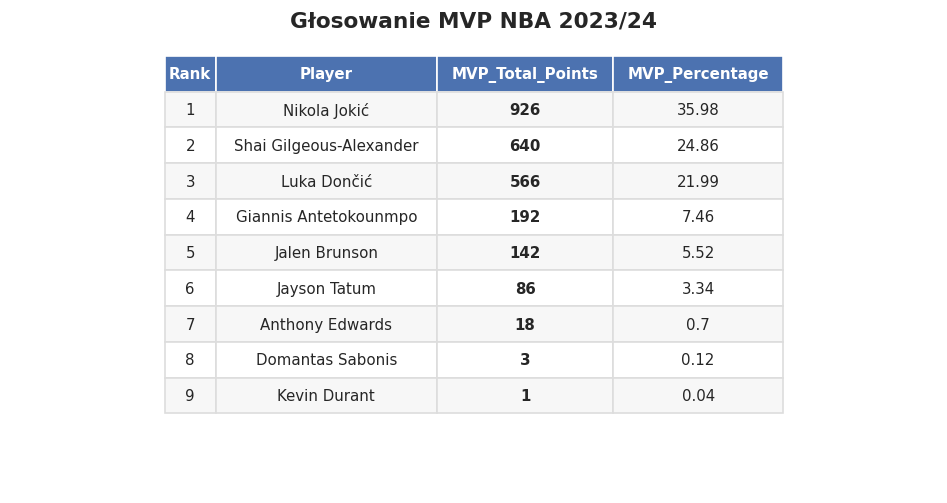

In [45]:
mvp_data = {
    "Rank": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Player': [
        'Nikola Jokić', 'Shai Gilgeous-Alexander', 'Luka Dončić', 
        'Giannis Antetokounmpo', 'Jalen Brunson', 'Jayson Tatum', 
        'Anthony Edwards', 'Domantas Sabonis', 'Kevin Durant'
    ],
    'MVP_Total_Points': [926, 640, 566, 192, 142, 86, 18, 3, 1]
}

print("\n=== MVP Votes 2023/24 ===\n")
mvp_df = pd.DataFrame(mvp_data)
mvp_df["MVP_Percentage"] = (mvp_df["MVP_Total_Points"] / mvp_df["MVP_Total_Points"].sum() * 100).round(2)
render_table(mvp_df, title="Głosowanie MVP NBA 2023/24",
             filename="tab_mvp_votes", highlight_col=2)

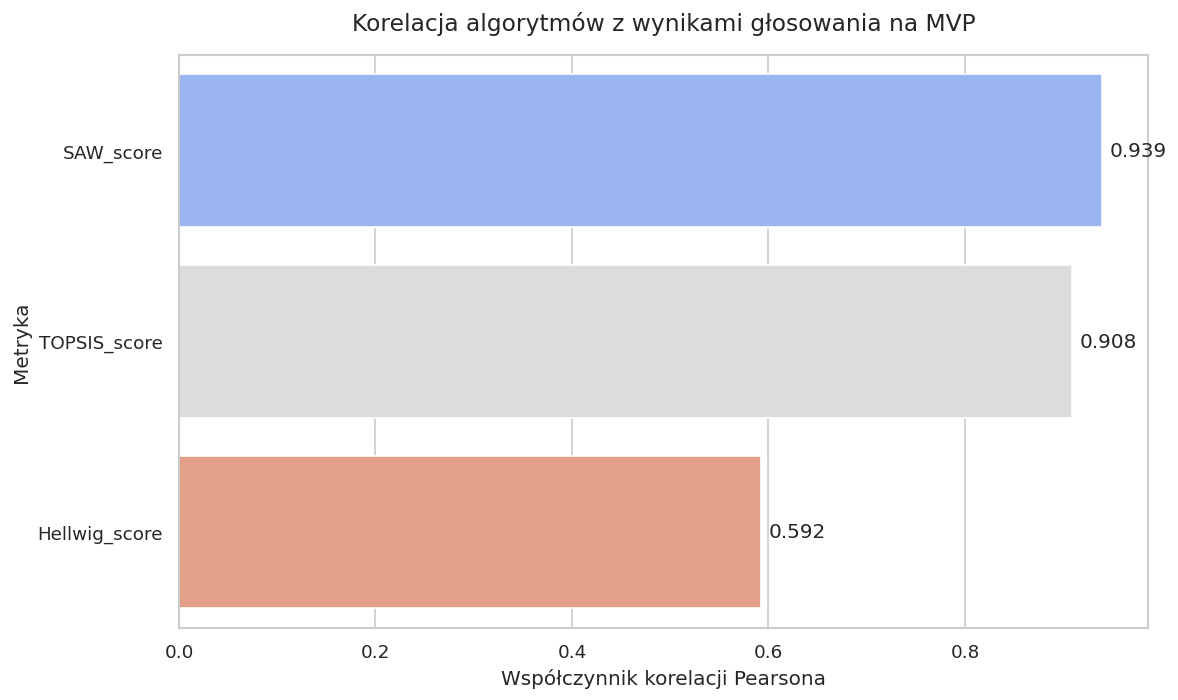

In [46]:
mvp_data = {
    'Player': [
        'Nikola Jokić', 'Shai Gilgeous-Alexander', 'Luka Dončić', 
        'Giannis Antetokounmpo', 'Jalen Brunson', 'Jayson Tatum', 
        'Anthony Edwards', 'Domantas Sabonis', 'Kevin Durant'
    ],
    'MVP_Total_Points': [926, 640, 566, 192, 142, 86, 18, 3, 1]
}
df_mvp = pd.DataFrame(mvp_data)

df_metrics = saw_df[['Player', 'SAW_score']].merge(
    topsis_df[['Player', 'TOPSIS_score']], on='Player'
).merge(
    hellwig_df[['Player', 'Hellwig_score']], on='Player'
)

df_mvp['Player'] = df_mvp['Player'].str.lower().str.strip()
df_metrics['Player'] = df_metrics['Player'].str.lower().str.strip()

df_merged = pd.merge(df_mvp, df_metrics, on='Player', how='inner')

korelacje = df_merged.corr(numeric_only=True)['MVP_Total_Points'].sort_values(ascending=False)

korelacje_filtered = korelacje.drop('MVP_Total_Points')


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=korelacje_filtered.values, 
    y=korelacje_filtered.index, 
    hue=korelacje_filtered.index,
    palette="coolwarm", 
    legend=False
)

plt.title('Korelacja algorytmów z wynikami głosowania na MVP', fontsize=14, pad=15)
plt.xlabel('Współczynnik korelacji Pearsona', fontsize=12)
plt.ylabel('Metryka', fontsize=12)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=5)

plt.tight_layout()

file_path = PLOTS_DIR / 'korelacja_mvp.png'

plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()


## 7. Podsumowanie

### 7.1. Główne wnioski

1. **Zgodność SAW i TOPSIS:** Metody SAW i TOPSIS, mimo różnych technik normalizacji (min-max vs. wektorowa), dają niemal identyczne rankingi (ρ Spearmana = 0,987). Obie wykorzystują te same wagi eksperckie, co jest dominującym czynnikiem kształtującym wynik.

2. **Odmienność Hellwiga:** Metoda Hellwiga, nie stosując wag eksperckich, nagradza graczy o zbalansowanym profilu statystycznym. Jarrett Allen (#1 w Hellwigu) jest modelowym przykładem - równomiernie wysoki poziom we wszystkich zmiennych, ale brak dominacji w najbardziej „medialnych" statystykach (PTS, AST).

3. **Ranking zagregowany (1/3 SAW + 1/3 TOPSIS + 1/3 Hellwig):** Uśrednienie trzech metod z równymi wagami daje stabilny ranking końcowy. Top 3:
   - **Nikola Jokić** (DEN, C) - dominuje w SAW i TOPSIS (#1), wysoko w Hellwigu (#4)
   - **LeBron James** (LAL, PF) - konsekwentnie w top 3 we wszystkich metodach
   - **Shai Gilgeous-Alexander** (OKC, PG) - #2 w Hellwigu dzięki zbalansowanemu profilowi

4. **Ranking per pozycja:** Analiza top 5 na każdej pozycji ujawnia różnice w rolach:
   - Centri (C) dominują ogólny ranking dzięki zbiórkom i eFG%
   - Rozgrywający (PG) wyróżniają się asystami, ale mają wyższe TOV
   - Shooting guardowie (SG) mają najtrudniejszą drogę do czołówki - brak dominacji w żadnej kategorii

5. **Wpływ wag:** Wagi eksperckie z dominacją PTS (0,25) i AST (0,18) premiują liderów ofensywnych. Obniżenie wagi destymulant (TOV = 0,05, PF = 0,05) oznacza, że gracze z wieloma stratami (Dončić, Embiid) nie są za to surowo karani w SAW/TOPSIS, ale są w Hellwigu.

6. **Obserwacje odstające:** Zidentyfikowano 11 obserwacji odstających (metoda IQR), ale zdecydowano o ich zachowaniu - w sporcie wartości skrajne reprezentują graczy elitarnych, a ich usunięcie zniekształciłoby ranking.

7. **Zgodność z wynikami głosowania MVP:** Metody z wagami eksperckimi (SAW, TOPSIS) silniej korelują z głosowaniem na MVP, ponieważ celnie odzwierciedlają ocenę ekspertów (promowanie liderów ofensywnych). Nieważona metoda Hellwiga premiuje zbalansowanych, wszechstronnych graczy, co rzadziej przekłada się na to najwyższe wyróżnienie indywidualne.

### 7.2. Ograniczenia

- Wagi eksperckie są subiektywne - inny ekspert mógłby przypisać inne wagi, zmieniając ranking SAW/TOPSIS.
- Dane obejmują jedynie statystyki „pudełkowe" (*box score*) - nie uwzględniają zaawansowanych metryk (np. BPM, VORP, WS).
- Filtracja (G ≥ 4, MP ≥ 15) eliminuje graczy z krótkim udziałem w play-offach, co może pominąć wartościowych rezerwowych.
- Ranking zagregowany z równymi wagami (1/3) daje metodom ważonym (SAW, TOPSIS) łączny wpływ 2/3, co faworyzuje podejście eksperckie nad nieważoną metodą Hellwiga.

## 8. Bibliografia

1. Dadelo, S., Turskis, Z., Zavadskas, E. K., & Dadelienė, R. (2014). Multi-criteria assessment and ranking system of sport team formation based on objective-measured values of criteria set. *Expert Systems with Applications*, 41(14), 6106–6113.

2. Fishburn, P. C. (1967). Additive utilities with incomplete product sets: Application to priorities and assignments. *Operations Research*, 15(3), 537–542.

3. Hellwig, Z. (1968). Zastosowanie metody taksonomicznej do typologicznego podziału krajów ze względu na poziom ich rozwoju oraz zasoby i strukturę wykwalifikowanych kadr. *Przegląd Statystyczny*, 15(4), 307–327.

4. Hwang, C. L., & Yoon, K. (1981). *Multiple Attribute Decision Making: Methods and Applications*. Springer-Verlag.

5. https://pr.nba.com/voting-results-2023-24-nba-regular-season-awards/

6. https://www.kaggle.com/datasets/vivovinco/2023-2024-nba-player-stats/data?select=2023-2024+NBA+Player+Stats+-+Playoffs.csv